# Analyzing results

### libraries

In [2]:
# change to the root directory of the project
import os
from pathlib import Path

cwd = Path.cwd()
#or set manual: 
#cwd = '.../ScanDy'

for parent in [cwd] + list(cwd.parents):
    if (parent / "data").exists():
        os.chdir(parent)
        break

print(Path.cwd())
import importlib
import os
from pathlib import Path

import matplotlib.patches as mpatches
from matplotlib.collections import PolyCollection
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import numpy as np

import seaborn as sns

from neurolib.optimize.evolution import Evolution
from neurolib.utils.parameterSpace import ParameterSpace

import scandy_pfc.models.ObjectModel as objectmodel_module
import scandy_pfc.models.model as base_model
import scandy_pfc.utils.dataclass as dataclass_module


import logging
logging.getLogger().setLevel(logging.ERROR)
logging.getLogger("pypet").setLevel(logging.ERROR)
logging.getLogger("deap").setLevel(logging.ERROR)
logging.getLogger("pypet.environment").setLevel(logging.ERROR)
logging.getLogger("pypet.storageservice.HDF5StorageService").setLevel(logging.ERROR)
logging.disable(logging.CRITICAL)
import warnings
warnings.simplefilter("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

import re

import random
from scipy import stats
from matplotlib.legend_handler import HandlerTuple
import seaborn as sns

dircl = ['xkcd:maroon', sns.color_palette("Dark2")[1], sns.color_palette("Dark2")[5], sns.color_palette("Dark2")[6] ]
mcl = ['xkcd:blue', 'xkcd:red']
MODEL = "obj" 

importlib.reload(dataclass_module)
Dataset = dataclass_module.Dataset
importlib.reload(base_model)
importlib.reload(objectmodel_module)
ObjectModel = objectmodel_module.ObjectModel

/mnt/raid/data/anina/ScanDy


------------------------

## Evolution analysis

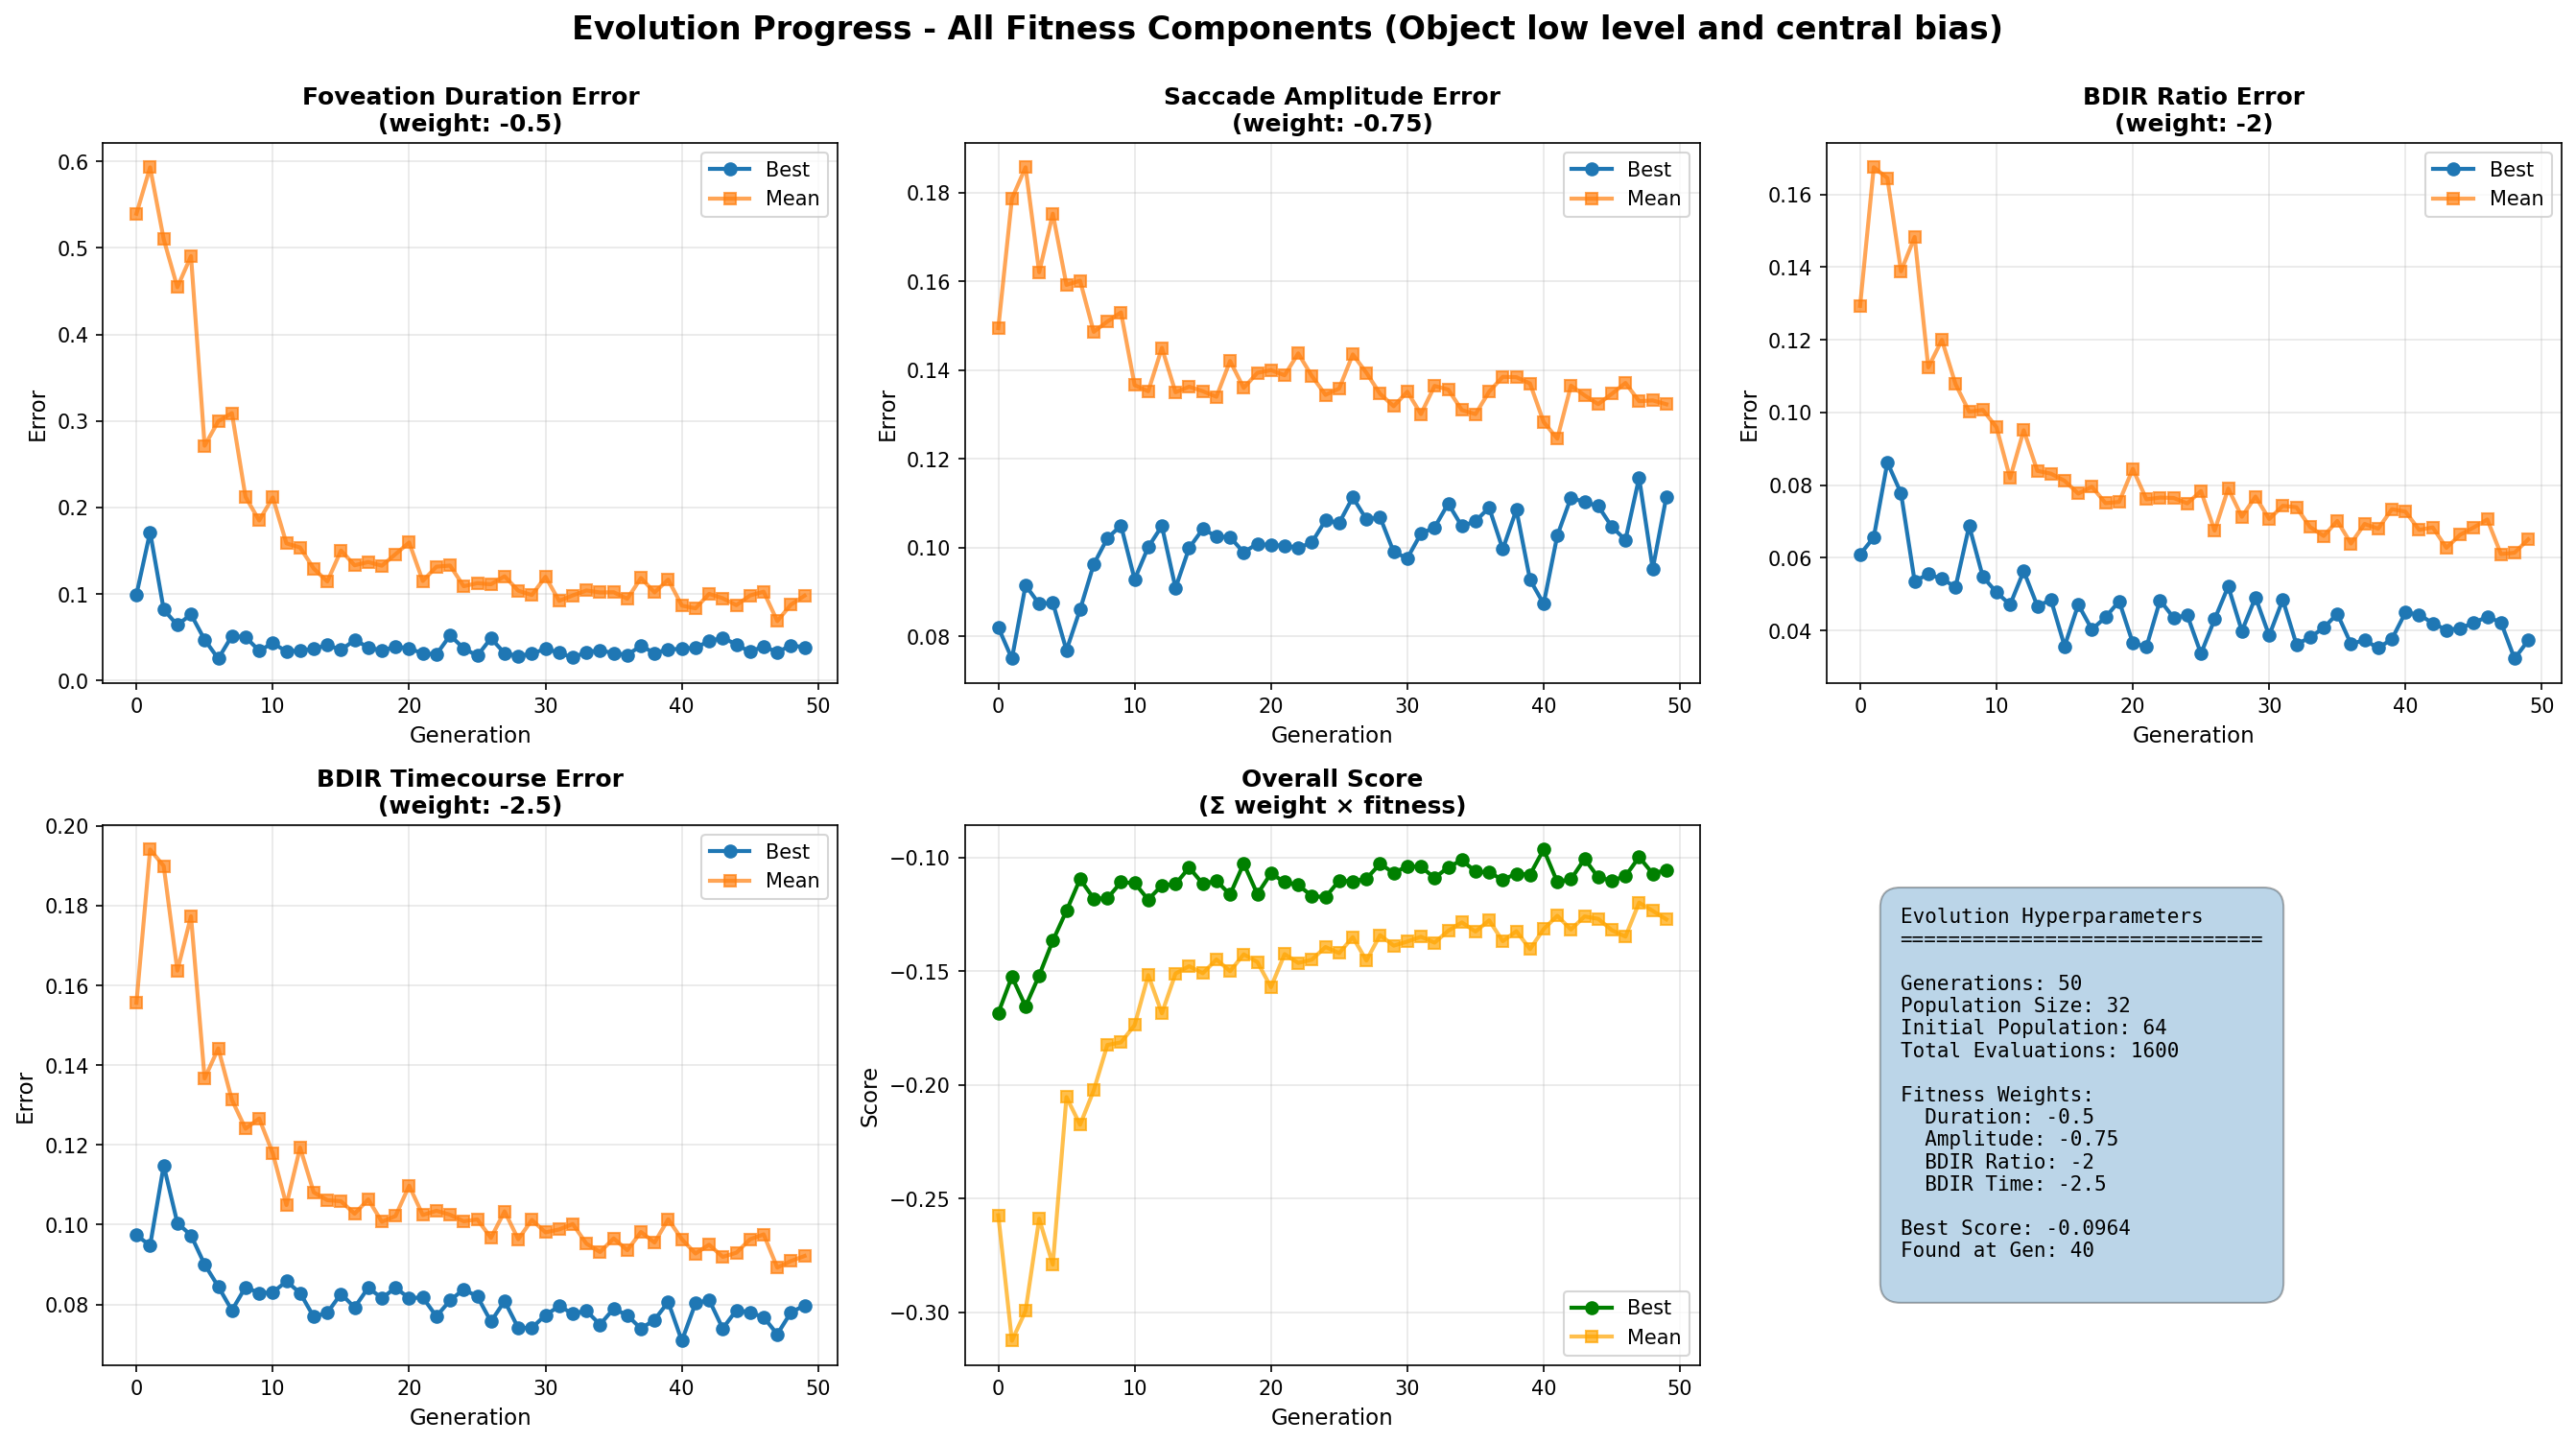

In [34]:
EVOLUTION_DILL_PATH = 'sorted_results/overfitting/evol_cb_s13__std0.8_imgseed10_young.dill'
naming = "Object low level and central bias"

evol = Evolution(lambda x: x, ParameterSpace(['mock'], [[0, 1]]))
evol = evol.loadEvolution(EVOLUTION_DILL_PATH)
df_evol = evol.dfEvolution(outputs=True)

# Fitness labels
fitness_value_dict = {
    'f0': 'Foveation Duration Error', 
    'f1': 'Saccade Amplitude Error', 
    'f2': 'BDIR Ratio Error', 
    'f3': 'BDIR Timecourse Error'
}

weights = evol.weightList 

# Determine number of fitness components
n_fitness = len(weights) if weights else 2

total_plots = n_fitness + 2
n_cols = 3
n_rows = int(np.ceil(total_plots / n_cols))

# Create figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5), dpi=150)
axes = axes.flatten()

# Plot fitness components
for i in range(n_fitness):
    ax = axes[i]
    ax.plot(df_evol.groupby('gen')[f'f{i}'].min(), label='Best', marker='o', linewidth=2)
    ax.plot(df_evol.groupby('gen')[f'f{i}'].mean(), label='Mean', marker='s', linewidth=2, alpha=0.7)
    ax.set_xlabel('Generation', fontsize=11)
    ax.set_ylabel('Error', fontsize=11)
    
    # Add weight to title if available
    title = fitness_value_dict.get(f'f{i}', f'Fitness {i}')
    if weights and len(weights) > i:
        title += f'\n(weight: {weights[i]})'
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

# Plot score
ax = axes[n_fitness]
ax.plot(df_evol.groupby('gen')['score'].max(), label='Best', marker='o', linewidth=2, color='green')
ax.plot(df_evol.groupby('gen')['score'].mean(), label='Mean', marker='s', linewidth=2, alpha=0.7, color='orange')
ax.set_xlabel('Generation', fontsize=11)
ax.set_ylabel('Score', fontsize=11)

# Add weight formula to score title
score_title = 'Overall Score'
if weights:
    score_title += f'\n(Σ weight × fitness)'
ax.set_title(score_title, fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Hyperparameters text box
ax = axes[n_fitness + 1]
ax.axis('off')

# Gather evolution info
n_generations = df_evol['gen'].max() + 1
n_individuals_per_gen = len(df_evol[df_evol['gen'] == 0])
total_evaluations = len(df_evol)
best_score = df_evol['score'].max()
best_gen = df_evol.loc[df_evol['score'].idxmax(), 'gen']

# Try to get other evolution parameters
pop_init_size = getattr(evol, 'POP_INIT_SIZE', 'N/A')
pop_size = getattr(evol, 'POP_SIZE', n_individuals_per_gen)
mutation_rate = getattr(evol, 'MUTATE_P', 'N/A')
crossover_rate = getattr(evol, 'MATE_P', 'N/A')

# Create info text
info_text = "Evolution Hyperparameters\n" + "="*30 + "\n\n"
info_text += f"Generations: {n_generations}\n"
info_text += f"Population Size: {pop_size}\n"
info_text += f"Initial Population: {pop_init_size}\n"
info_text += f"Total Evaluations: {total_evaluations}\n\n"

if weights:
    info_text += "Fitness Weights:\n"
    weight_labels = ['Duration', 'Amplitude', 'BDIR Ratio', 'BDIR Time']
    for i in range(len(weights)):
        if i < len(weight_labels):
            info_text += f"  {weight_labels[i]}: {weights[i]}\n"
        else:
            info_text += f"  Fitness {i}: {weights[i]}\n"
    info_text += "\n"

info_text += f"Best Score: {best_score:.4f}\n"
info_text += f"Found at Gen: {int(best_gen)}\n"

# Display text in box
ax.text(0.1, 0.5, info_text, 
        fontsize=10, 
        verticalalignment='center',
        family='monospace',
        bbox=dict(boxstyle='round', alpha=0.3, pad=1))

# Turn off any unused subplots
for i in range(n_fitness + 2, len(axes)):
    axes[i].axis('off')

# Add weights info to main title if available
main_title = f'Evolution Progress - All Fitness Components ({naming})'
plt.suptitle(main_title, fontsize=16, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()

In [6]:
evol = Evolution(lambda x: x, ParameterSpace(['mock'], [[0, 1]]))
evol = evol.loadEvolution(f'{EVOLUTION_DILL_PATH}')
df_evol = evol.dfEvolution(outputs=True).copy()
df_top = df_evol.sort_values('score', ascending=False)[:3]
print(df_top)

     ddm_thres   ddm_sig   att_dva   ior_decay  ior_inobj     score   id  gen  \
514   3.829361  0.312336  8.800344  185.969585   0.789326 -0.051637  530   32   
573   3.512657  0.374957  7.990774  196.430301   0.811956 -0.052047  589   35   
628   3.881252  0.425252  8.494717  155.058662   0.800163 -0.052590  644   39   

            B         D         I         R        f0        f1  
514  0.211215  0.171989  0.438364  0.178432  0.033114  0.070161  
573  0.203934  0.167568  0.421594  0.206904  0.023537  0.080557  
628  0.170299  0.182743  0.430866  0.216091  0.022106  0.083074  


------------------------

In [77]:
import os
import glob
import pandas as pd

# Find all .dill files in the directory
dill_files = glob.glob('sorted_results/overfitting/*.dill')

# Fitness labels
fitness_value_dict = {
    'f0': 'Foveation Duration', 
    'f1': 'Saccade Amplitude', 
    'f2': 'BDIR Ratio', 
    'f3': 'BDIR Timecourse'
}

# Collect results
results = []

for file_path in dill_files:
    try:
        # Extract filename for display
        filename = os.path.basename(file_path)
        
        evol = Evolution(lambda x: x, ParameterSpace(['mock'], [[0, 1]]))
        evol = evol.loadEvolution(file_path)
        df_evol = evol.dfEvolution(outputs=True)
        weights = evol.weightList
        
        # Get the best individual
        best_idx = df_evol['score'].idxmax()
        best_individual = df_evol.loc[best_idx]
        
        # Store result
        result = {
            'File': filename,
            'Overall Score': best_individual['score'],
            'Generation': int(best_individual['gen'])
        }
        
        # Add individual fitness components
        n_fitness = len(weights) if weights else 4
        for i in range(n_fitness):
            col_name = fitness_value_dict.get(f'f{i}', f'f{i}')
            result[col_name] = best_individual[f'f{i}']
        
        results.append(result)
        
    except Exception as e:
        print(f"ERROR loading {file_path}: {e}")

# Create DataFrame and sort by overall score
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Overall Score', ascending=False)

# Display table
print("="*120)
print("COMPARISON OF ALL EVOLUTION FILES")
print("="*120)
print(df_results.to_string(index=False))
print("="*120)

# Optionally save to CSV
df_results.to_csv('evolution_comparison.csv', index=False)

COMPARISON OF ALL EVOLUTION FILES
                                                 File  Overall Score  Generation  Foveation Duration  Saccade Amplitude  BDIR Ratio  BDIR Timecourse
             evol_cb_s13__std0.8_imgseed10_young.dill      -0.096445          40            0.047679           0.119818    0.047451         0.070869
             evol_cb_s13__std0.5_imgseed10_young.dill      -0.098303          48            0.053555           0.138436    0.039171         0.073706
               evol_cb_s13__std1_imgseed10_young.dill      -0.098542          41            0.043094           0.113785    0.053155         0.072388
       evol_not05_cb_s13__std0.2_imgseed10_young.dill      -0.100337          49            0.036312           0.118432    0.048235         0.079158
       evol_not05_cb_s13__std0.5_imgseed10_young.dill      -0.100562          43            0.053766           0.127939    0.043496         0.076968
evol_not05_obj_ll_cb_s13__std0.2_imgseed10_young.dill      -0.105893    

In [6]:
import os
if os.getcwd().split("/")[-1] == "examples":
    os.chdir('..')
import importlib
import os
import pickle
import random

import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.legend_handler import HandlerTuple

import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

from neurolib.optimize.evolution import Evolution
from neurolib.utils.parameterSpace import ParameterSpace

import scandy_pfc.models.ObjectModel as objectmodel_module
import scandy_pfc.models.model as base_model
import scandy_pfc.utils.dataclass as dataclass_module
import scandy_pfc.utils.functions as uf

import argparse

imglist = ['plank', 'fingerTapping', 'statues', 'work2', 'pedestrian', 'chessBoard', 'youtube', 'axolotl', 'reindeers', 'ballBalance', 'bench', 'birdFalling', 'elevatorEmpty', 'mokaPot', 'toytrainHouses', 'ventilator', 'penDrawing', 'dino', 'trafficLight']
dva = 47.7 
random.seed(12345)
trainlist = sorted(random.sample(imglist, 10))  
testlist = sorted([vidname for vidname in imglist if vidname not in trainlist])
datadict = {
    "PATH":"PictureExample/PictureExample_Resized/",  
    'FPS' : 30,
    'PX_TO_DVA' : ((dva * 0.8) / 1920)*4,  
    'FRAMES_ALL_VIDS' : 150,
    'VID_EXTENSION' : 'png',
    'gt_foveation_df' :'parkinson_data/df_img_fovs_psycsci.csv',
    'dataformat': 'picture', #'video', 'both' #<-- filter for video/picture
    'NAME_COL' : 'scene', #<-- changed from 'video' to 'scene' from ScanDy to ScanDy with Pfc
    'trainset' : trainlist,
    'testset' : testlist,
    'used_videos': imglist, 
    'startpos': 'random'
}
VidCom = Dataset(datadict)

evol = Evolution(lambda x: x, ParameterSpace(['mock'], [[0, 1]]))
evolution = evol.loadEvolution(f"sorted_results/fade_scale4/evol_par_rand_fade2_cb_s13__std0.5_imgseed10_young.dill")


# ------- Simulate model with top parameter ------------ 

model = ObjectModel(VidCom)
parameters = ["ddm_thres", "ddm_sig", "att_dva", "ior_decay", "ior_inobj"]
model.params["featuretype"] = None
model.params["feature_std"] = 0.5
model.params["feature_fade"] = True
model.params["centerbias"] = "anisotropic_default"
model.params["startpos"] = "random"
df_evol = evolution.dfEvolution(outputs=True).copy()

for rang in range(3):
    for par in parameters:
                model.params[par] = df_evol.sort_values("score", ascending=False).iloc[rang][
                    par
                ] 
    filename = f"sorted_results/fade_scale4/best_par_rand_fade2_cb_s13__std0.5_imgseed10_{rang}.pkl"
    if os.path.isfile(filename) == False:
        model.run('all', seeds=[s for s in range(1,13)], overwrite_old=True)
        with open(filename, 'wb') as file:
            pickle.dump(model.result_dict, file)
        df_filename = f"sorted_results/fade_scale4/best_par_rand_fade2_cb_s13__std0.5_imgseed10_{rang}.csv.gz"
        if os.path.isfile(df_filename) == False:
            model.evaluate_all_to_df()
            model.result_df.to_csv(
                df_filename, compression="gzip", index=False
            )


Video column is set to: scene


## Model Fitting 

In [30]:
folder = Path("sorted_results/bigger_trainset_scale4/")

dill_files = [f.name for f in folder.iterdir() if f.suffix == ".dill"]

print(dill_files)


['evol_par_rand_obj_ll_cb_s13__std0.5_imganimated_pd_off.dill', 'evol_par_rand_obj_ll_s13__std0.5_imganimated_pd_off.dill', 'evol_par_rand_obj_ll_cb_s13__std0.5_imganimated_old.dill', 'evol_par_rand_cb_s13__std0.5_imganimated_old.dill', 'evol_par_rand_obj_ll_cb_s13__std0.5_imganimated_young.dill', 'evol_par_rand_obj_hl_s13__std0.5_imganimated_young.dill', 'evol_par_rand_obj_ll_s13__std0.5_imganimated_pd_on.dill', 'evol_par_rand_obj_hl_s13__std0.5_imganimated_pd_off.dill', 'evol_par_rand_cb_s13__std0.5_imganimated_pd_off.dill', 'evol_par_rand_obj_hl_s13__std0.5_imganimated_pd_on.dill', 'evol_par_rand_cb_s13__std0.5_imganimated_pd_on.dill', 'evol_par_rand_obj_hl_s13__std0.5_imganimated_old.dill', 'evol_par_rand_obj_ll_cb_s13__std0.5_imganimated_pd_on.dill', 'evol_par_rand_cb_s13__std0.5_imganimated_young.dill', 'evol_par_rand_obj_ll_s13__std0.5_imganimated_young.dill']


In [ ]:
#basic_scale 4
['par_cb_s10__std1_imgseed10', 'cb_s10__std1_imgseed10',
 'obj_ll_s10__std1_imgseed10', 'par_obj_ll_s10__std1_imgseed10',
 'par_obj_hl_s10__std1_imgseed10', 'obj_hl_s10__std1_imgseed10',
 'par_obj_ll_cb_s10__std1_imgfull', 'par_cb_s10__std1_imgfull', 'par_obj_hl_s10__std1_imgfull',
  'obj_ll_cb_s10__std1_imgseed10', 'par_obj_ll_cb_s10__std1_imgseed10']

#std_scale4
['par_obj_hl_s10__std0.8_imgseed10', 'par_obj_ll_s10__std0.8_imgseed10', 
 'par_obj_hl_s10__std0.5_imgseed10', 'par_cb_s10__std0.2_imgseed10', 
 'par_obj_ll_cb_s10__std0.8_imgseed10', 
 'par_cb_s10__std0.8_imgseed10', 'par_obj_ll_cb_s10__std0.2_imgseed10', 
 'par_obj_ll_s10__std0.5_imgseed10', 'par_cb_s10__std0.5_imgseed10',
 'par_obj_hl_s10__std0.2_imgseed10', 'par_obj_ll_s10__std0.2_imgseed10', 
 'par_obj_ll_cb_s10__std0.5_imgseed10']

#randomstart_scale4
#all
['par_rand_obj_ll_s10__std0.5_imgseed10', 
 'par_rand_obj_ll_cb_s10__std0.5_imgseed10', 
 'par_rand_obj_hl_s10__std0.5_imgseed10', 
 'par_rand_cb_s10__std0.5_imgseed10'] 
#young
['par_human_cb_s10__std0.5_imgseed10', 'par_human_obj_hl_s10__std0.5_imgseed10', 'par_human_obj_ll_cb_s10__std0.5_imgseed10'] 

### still running!
#bigger_trainset_scale4
['par_rand_obj_ll_cb_s13__std0.5_imganimated', 'par_rand_obj_ll_s13__std0.5_imganimated', 
 'par_rand_cb_s13__std0.5_imganimated_old.dill',
 'par_rand_obj_hl_s13__std0.5_imganimated']

##BDIR_fit
#all
['par_rand_weight_obj_ll_cb_s10__std0.5_imgseed10']
#young
['par_rand_obj_ll_cb_s10__std0.5_seed10', 
 'par_rand_obj_ll_cb_s10__std0.5_imgseed10']
['evol100_par_rand_weight_obj_ll_cb_s10__std0.5_imgseed10']

##fade_scale4
['par_rand_fade2_15_obj_ll_cb_s10__std1_imgseed10',
 'par_rand_fade2_15_cb_s10__std0.5_imgseed10', 
 'par_rand_fade3_18_cb_s10__std0.5_imgseed10', 
 'par_rand_fade2_5_obj_ll_cb_s13__std1_imgseed10', 
 'par_rand_fade2_5_obj_ll_cb_s13__std0.5_imgseed10',
 'par_rand_fade2_cb_s13__std0.5_imgseed10', 
 'par_rand_fade3_18_obj_ll_cb_s13__std1_imgseed10', 
 'par_rand_fade3_18_cb_s10__std1_imgseed10', 
 'par_rand_fade2_15_obj_ll_cb_s10__std0.5_imgseed10', 
 'par_rand_fade3_18_obj_ll_cb_s13__std0.5_imgseed10', 
 'par_rand_fade2_15_cb_s10__std1_imgseed10']

##frames_scale4
['par_cb_s10_1.0s__std0.5_imgseed10', 'par_obj_ll_s10_1.0s__std0.5_imgseed10',
 'gen_par_obj_hl_s10_1.0s__std0.5_imgseed10', 'par_obj_hl_s10_1.0s__std0.5_imgseed10', 
 'par_obj_ll_cb_s10_1.0s__std0.5_imgseed10', 'gen_par_obj_hl_s10_0.5s__std0.5_imgseed10']

##overfitting
['not05_obj_ll_cb_s13__std0.2_imgseed10', 'not05_cb_s13__std0.8_imgseed10']

['not05_obj_ll_cb_s13__std0.5_imgseed10', 
 'obj_ll_cb_s13__std0.8_imgseed10',
'obj_ll_cb_s13__std1_imgseed10'
 'obj_ll_cb_s13__std0.5_imgseed10',  
 
'obj_hl_s13__std0.5_imgseed10', 
  'obj_hl_s13__std0.8_imgseed10', 
  'obj_hl_s13__std1_imgseed10',  

 'obj_ll_s13__std0.5_imgseed10',  
 'obj_ll_s13__std1_imgseed10', 
 'obj_ll_s13__std0.8_imgseed10', 
 
 'cb_s13__std0.8_imgseed10', 
 'cb_s13__std0.5_imgseed10', 
 'cb_s13__std1_imgseed10', 
  'not05_cb_s13__std0.5_imgseed10', , 
 'not05_cb_s13__std0.2_imgseed10', 
 ]




#### Set Constants

In [31]:
# Configuration
folder = "sorted_results/bigger_trainset_scale4/"
EVOLUTION_NAME_DILL = "evol_{naming}"
SIMULATE_WITH_BEST_PARAMS = "best_{naming}_"
PDF_FILENAME = "{folder}analysis_report_{name}_{key}.pdf"
FOLDER_PATH = "PictureExample/picture"
ITERATIONS = 3
REPORT_PAR_DECIMALS = [3, 3, 2, 1, 2]
PARAMETERS = ['ddm_thres', 'ddm_sig', 'att_dva', 'ior_decay', 'ior_inobj']
dva_resize = 4 # resizing factor of the images for the model simulation

DATAFRAME_FILES = {
    "young": 'parkinson_data/df_img_fovs_psycsci.csv',
    "old": 'parkinson_data/df_img_fovs_controls.csv',
    "pd_on": 'parkinson_data/df_img_fovs_parkinson_with.csv',
    "pd_off": 'parkinson_data/df_img_fovs_parkinson_without.csv'
}

DVA_VALUES = {
    "young": 47.7,
    "old": 40.45,
    "pd_on": 40.45,
    "pd_off": 40.45
}
random.seed(12345)


#### Functions

In [3]:
def get_image_list(folder_path):
    """Get list of image files from folder."""
    return [os.path.splitext(f)[0] for f in os.listdir(folder_path) 
            if os.path.isfile(os.path.join(folder_path, f)) and f.endswith(".png")]

def create_train_test_split(imglist, seed=12345, train_size=64):
    """Create train/test split from image list."""
    random.seed(seed)
    trainlist = sorted(random.sample(imglist, train_size))
    testlist = sorted([vidname for vidname in imglist if vidname not in trainlist])
    return trainlist, testlist

def initialize_datasets(dataframe_files, dva_values, trainlist, testlist, imglist, dva_resize, frames=150):
    """Initialize Dataset objects for all groups."""
    VidCom = {}
    
    for key, gt_foveation_df in dataframe_files.items():
        print(f"Initializing dataset: {key}")
        dva = dva_values[key]
        
        datadict = {
            "PATH": "PictureExample/",
            'FPS': 30,
            'PX_TO_DVA': ((dva * 0.8) / 1920) * dva_resize,
            'FRAMES_ALL_VIDS': frames,
            'VID_EXTENSION': 'png',
            'gt_foveation_df': gt_foveation_df,
            'dataformat': 'picture',
            'NAME_COL': 'scene',
            'trainset': trainlist,
            'testset': testlist,
            'used_videos': imglist,
            'startpos': "random"
        }
        VidCom[key] = Dataset(datadict)
    
    return VidCom

def fit_distributions(data_set):
    """Fit gamma and log-normal distributions to ground truth data."""
    gt_amp_dva = data_set.gt_foveation_df["sac_amp_dva"].dropna().values
    gt_amp_dva = gt_amp_dva[gt_amp_dva > 0.5]
    gt_dur_ms = data_set.gt_foveation_df["duration_ms"].dropna().values
    gt_dur_ms_clean = gt_dur_ms[np.isfinite(gt_dur_ms) & (gt_dur_ms > 0)]
    
    ampfit = stats.gamma.fit(gt_amp_dva, floc=0)
    durfit = stats.norm.fit(np.log10(gt_dur_ms_clean))
    
    return ampfit, durfit

def load_evolution_results(evolution_name_dill, simulate_with_best_params, key, iterations, VidCom, verbose=True):
    """Load evolution results and compute foveation categories."""
    DILLNAME = f'{evolution_name_dill}_{key}.dill'
    
    
    evol = Evolution(lambda x: x, ParameterSpace(['mock'], [[0, 1]]))
    evol = evol.loadEvolution(f'{folder}{DILLNAME}')
    df_evol = evol.dfEvolution(outputs=True).copy()
    df_top = df_evol.sort_values('score', ascending=False)[:iterations]
    if verbose: 
        print(f'Loaded evolution results for {key}:')
        print(df_top)

    subjects_fovcat_train = list(VidCom[key].get_fovcat_ratio("train").values())
    subjects_fovcat_test = list(VidCom[key].get_fovcat_ratio("test").values())
    
    train_fovcats = []
    test_fovcats = []
    
    for i in range(iterations):
        df_res = pd.read_csv(f'{folder}{simulate_with_best_params}{key}_{i}.csv.gz', compression='gzip')
        model = ObjectModel(VidCom[key])
        
        model.result_df = df_res[df_res['video'].isin(VidCom[key].trainset)]
        train_fovcats.append(np.array(list(model.get_fovcat_ratio().values())))
        
        model.result_df = df_res[df_res['video'].isin(VidCom[key].testset)]
        test_fovcats.append(np.array(list(model.get_fovcat_ratio().values())))
    
    df_top['train_fov_cat'] = train_fovcats
    df_top['test_fov_cat'] = test_fovcats
    
    mean_fovcat_train = np.mean(np.array(train_fovcats), axis=0)
    mean_fovcat_test = np.mean(np.array(test_fovcats), axis=0)
    
    return df_top, mean_fovcat_train, mean_fovcat_test, subjects_fovcat_train, subjects_fovcat_test

def create_fovcat_comparison_plot(VidCom, mean_fovcats_train, mean_fovcats_test, groups, return_fig=True):
    """Create bar plot comparing model and human foveation categories."""
    train_rows = []
    test_rows = []
    labels = []

    for key in groups:
        human_train = list(VidCom[key].get_fovcat_ratio("train").values())
        
        model_train = mean_fovcats_train[key].tolist()  
        
        train_rows.append(model_train)
        labels.append(f"{key} – Model")
        train_rows.append(human_train)
        labels.append(f"{key} – Human")
        
        model_test = mean_fovcats_test[key].tolist()
        human_test = list(VidCom[key].get_fovcat_ratio("test").values())
        
        test_rows.append(model_test)
        test_rows.append(human_test)
    
    df_fovcats_train = pd.DataFrame(train_rows, index=labels, columns=['B', 'D', 'I', 'R'])
    df_fovcats_test = pd.DataFrame(test_rows, index=labels, columns=['B', 'D', 'I', 'R'])
    
    legend_handles = [
        mpatches.Patch(color=dircl[0], label='Background'),
        mpatches.Patch(color=dircl[1], label='Detection'),
        mpatches.Patch(color=dircl[2], label='Inspection'),
        mpatches.Patch(color=dircl[3], label='Return'),
    ]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=150, sharey=True)
    
    def plot_with_labels(df, ax, alpha=1.0):
        bars = ax.barh(df.index, df['B'], color=dircl[0], alpha=alpha)
        bars_D = ax.barh(df.index, df['D'], left=df['B'], color=dircl[1], alpha=alpha)
        bars_I = ax.barh(df.index, df['I'], left=df[['B', 'D']].sum(axis=1), color=dircl[2], alpha=alpha)
        bars_R = ax.barh(df.index, df['R'], left=df[['B', 'D', 'I']].sum(axis=1), color=dircl[3], alpha=alpha)
        
        def add_labels(bars, values, left):
            for bar, val, start in zip(bars, values, left):
                if val == 0:
                    continue
                x = start + val / 2
                y = bar.get_y() + bar.get_height() / 2
                color = "white" if val > 0.15 else "black"
                ax.text(x, y, f"{val:.2f}", ha='center', va='center', fontsize=7, color=color)
        
        add_labels(bars, df['B'], np.zeros(len(df)))
        add_labels(bars_D, df['D'], df['B'])
        add_labels(bars_I, df['I'], df[['B', 'D']].sum(axis=1))
        add_labels(bars_R, df['R'], df[['B', 'D', 'I']].sum(axis=1))
    
    plot_with_labels(df_fovcats_train, axes[0], alpha=1.0)
    axes[0].set_title("Training set")
    axes[0].set_xlabel("Ratio of events")
    axes[0].set_frame_on(False)
    
    plot_with_labels(df_fovcats_test, axes[1], alpha=0.4)
    axes[1].set_title("Test set")
    axes[1].set_xlabel("Ratio of events")
    axes[1].set_frame_on(False)
    
    fig.legend(handles=legend_handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.07))
    plt.tight_layout()
    if return_fig: 
        return fig
    else: 
        plt.show()

def create_violin_plots(VidCom, evolution_name_dill, simulate_with_best_params, groups, iterations=3, return_fig=True):
    """Create violin plots comparing foveation categories across train/test sets."""
    
    fig, axes = plt.subplots(1, len(groups), sharex=True, sharey=True, 
                            figsize=(5*len(groups), 5), dpi=200)
    
    if len(groups) == 1:
        axes = [axes]
    
    plt.subplots_adjust(wspace=0.25, left=0.07, right=0.97, top=0.88, bottom=0.18)
    
    for ax_i, key in enumerate(groups):
        ax = axes[ax_i]
        
        df_top, _, _, subjects_fovcat_train, subjects_fovcat_test = load_evolution_results(
            evolution_name_dill, simulate_with_best_params, key, iterations, VidCom, verbose =False
        )
        
        train_rel_fovcat = [
            df_top['train_fov_cat'].iloc[indv] / np.array(subjects_fovcat_train) 
            for indv in range(iterations)
        ]
        
        test_rel_fovcat = [
            df_top['test_fov_cat'].iloc[indv] / np.array(subjects_fovcat_test) 
            for indv in range(iterations)
        ]
        
        df_train = pd.DataFrame(
            index=[f'Top {t}' for t in range(iterations)],
            columns=['B', 'D', 'I', 'R'], 
            data=train_rel_fovcat
        ).assign(Data='training set')
        
        df_test = pd.DataFrame(
            index=[f'Top {t}' for t in range(iterations)],
            columns=['B', 'D', 'I', 'R'], 
            data=test_rel_fovcat
        ).assign(Data='test set')
        
        cdf = pd.concat([df_test, df_train])
        mdf = pd.melt(cdf, id_vars=['Data'], var_name='fov_cat')
        
        sns.violinplot(x="fov_cat", y="value", hue="Data", data=mdf, ax=ax, 
                      split=True, linewidth=1, 
                      palette={"test set": dircl[0], "training set": ".85"})
        
        for ind, violin in enumerate(ax.findobj(PolyCollection)):
            rgb = to_rgb(dircl[ind // 2])
            if ind % 2 == 0:  # Test set - lighter color
                rgb = 0.5 + 0.5 * np.array(rgb)
            violin.set_facecolor(rgb)
        
        ax.set_yscale('log')
        ax.set_ylim(0.15, 5.2)
        ax.set_yticks([0.25, 0.5, 1, 1.5, 2])
        ax.set_yticklabels([0.25, 0.5, 1, 1.5, 2])
        ax.axhline(1, color='k', ls=':')
        ax.set_xlabel('')
        ax.set_title(f'{key.capitalize()}')
        
        if ax_i == 0:
            ax.set_ylabel('Fraction of viewing time\nrelative to human data', size=8)
        else:
            ax.set_ylabel('')
        
        # Legend only for second subplot
        if ax_i == 1 or len(groups) == 1:
            legend_handles = [
                Patch(facecolor=to_rgb(dircl[0]), edgecolor='none', label="Training set"),
                Patch(facecolor=0.5 + 0.5*np.array(to_rgb(dircl[0])), 
                     edgecolor='none', label="Test set")
            ]
            ax.legend(bbox_to_anchor=(1, 0), loc='lower right', frameon=False,
                     handles=legend_handles, fontsize=9)
        else:
            if ax.get_legend():
                ax.get_legend().remove()
    
    fig.text(0.5, -0.05, 'Foveation category', size=8, ha='center')
    sns.despine()
    plt.tight_layout()
    
    if return_fig:
        return fig
    else:
        plt.show()

def get_BDIR_per_frames(df, fps=30):
    """Calculate BDIR ratios per frame."""
    cat_col = 'fov_category' if 'fov_category' in df.columns else 'fov_cat'
    start_col = 'frame_start' if 'frame_start' in df.columns else 't_start'
    end_col = 'frame_end' if 'frame_end' in df.columns else 't_end'
    
    use_ms = start_col == 't_start'
    
    if use_ms:
        max_frame = int(df[end_col].max() / 1000 * fps) + 1
    else:
        max_frame = int(df[end_col].max()) + 1
    
    BDIR_per_frames = np.zeros((4, max_frame))
    bdir_to_row = {'B': 0, 'D': 1, 'I': 2, 'R': 3}
    
    for index, row in df.iterrows():
        if use_ms:
            frame_start = int(row[start_col] / 1000 * fps)
            frame_end = int(row[end_col] / 1000 * fps)
        else:
            frame_start = int(row[start_col])
            frame_end = int(row[end_col])
        
        frame_start = max(0, min(frame_start, max_frame - 1))
        frame_end = max(0, min(frame_end, max_frame - 1))
        
        BDIR_per_frames[bdir_to_row[row[cat_col]], frame_start:frame_end + 1] += 1
    
    denominator = np.sum(BDIR_per_frames, axis=0)
    denominator[denominator == 0] = 1
    BDIR_ratios_per_frames = 100 * BDIR_per_frames / denominator
    
    return BDIR_ratios_per_frames

def get_object_per_frames(df, fps=30, scene='ballBalance', scene_col='scene'):
    """
    Creates a timeline showing which objects are viewed at each frame.
    Returns a matrix where each row represents an object (sorted per scene) and columns are frames.
    scene_col = scene in human ground data and video else
    """
    obj_col = 'obj' if 'obj' in df.columns else 'object'
    start_col = 'frame_start' if 'frame_start' in df.columns else 't_start'
    end_col = 'frame_end' if 'frame_end' in df.columns else 't_end'
    cat_col = 'fov_category' if 'fov_category' in df.columns else 'fov_cat'
        
    use_ms = start_col == 't_start'
    max_frame = int(df[end_col].max() / 1000 * fps) + 1 if use_ms else int(df[end_col].max()) + 1
    
    df_scene = df[df[scene_col] == scene]
    all_objects = df_scene[obj_col].drop_duplicates().tolist()
    obj_to_row = {obj: i for i, obj in enumerate(all_objects)}
       
    object_per_frames = np.zeros((len(all_objects), max_frame))
    
    for _, row in df_scene.iterrows():
        frame_start = int(row[start_col] / 1000 * fps) if use_ms else int(row[start_col])
        frame_end = int(row[end_col] / 1000 * fps) if use_ms else int(row[end_col])
        frame_start = max(0, min(frame_start, max_frame - 1))
        frame_end = max(0, min(frame_end, max_frame - 1))
        object_per_frames[obj_to_row[row[obj_col]], frame_start:frame_end+1] += 1
    
    denominator = np.sum(object_per_frames, axis=0)
    denominator[denominator == 0] = 1
    object_ratios_per_frames = 100 * object_per_frames / denominator
    
    return object_ratios_per_frames, all_objects

def plot_scene_all_groups(VidCom, groups, run_ids, scene_name='plank', fps=30, return_fig=True):
    """
    Plot object viewing for a single scene across all groups.
    Shows human and model side-by-side for each group.
    Objects are colored according to their BDIR category.
    
    Parameters:
    - VidCom: dictionary with group data
    - groups: list of group names
    - run_ids: list of result file paths for each group
    - scene_name: str, the scene to plot
    - fps: frames per second for time conversion
    """
    n_groups = len(groups)
    fig, axs = plt.subplots(n_groups, 2, dpi=200, figsize=(16, 4*n_groups), 
                            sharex=True, sharey=True)
    
    # Handle single group case
    if n_groups == 1:
        axs = axs.reshape(1, -1)
    
 
    for group_idx, group_name in enumerate(groups):
        df_human_scene = pd.concat([
            VidCom[group_name].train_foveation_df,
            VidCom[group_name].test_foveation_df
        ])
        
        df_model = pd.read_csv(f'{folder}{run_ids[group_idx]}.csv.gz', compression='gzip')
        
        try:
            ratios_human, objects_human = get_object_per_frames(
                df_human_scene, fps=fps, scene=scene_name, scene_col='scene'
            )
            ratios_model, objects_model = get_object_per_frames(
                df_model, fps=fps, scene=scene_name, scene_col='video'
            )
            
            ax_human = axs[group_idx, 0]
            for i, obj in enumerate(objects_human):
                ax_human.plot(ratios_human[i], lw=2, label=obj, alpha=0.8)
            ax_human.set_title(f'{group_name} - Human (Scene: {scene_name})', fontsize=12)
            ax_human.set_ylabel('Percentage')
            ax_human.set_ylim(0, 100)
            ax_human.legend(title='Objects', bbox_to_anchor=(1.05, 1), 
                          loc='upper left', fontsize=8)
            
            ax_model = axs[group_idx, 1]
            for i, obj in enumerate(objects_model):
                ax_model.plot(ratios_model[i], lw=2, label=obj, alpha=0.8)
            ax_model.set_title(f'{group_name} - Model (Scene: {scene_name})', fontsize=12)
            ax_model.set_ylim(0, 100)
            ax_model.legend(title='Objects', bbox_to_anchor=(1.05, 1), 
                          loc='upper left', fontsize=8)
                
        except Exception as e:
            print(f"Warning: Could not plot {scene_name} for {group_name}: {e}")
            axs[group_idx, 0].text(0.5, 0.5, f'No data for {scene_name}', 
                                   ha='center', va='center')
            axs[group_idx, 1].text(0.5, 0.5, f'No data for {scene_name}', 
                                   ha='center', va='center')
    
    axs[-1, 0].set_xlabel('Time [frames]', fontsize=12)
    axs[-1, 1].set_xlabel('Time [frames]', fontsize=12)
   
    fig.suptitle(f'Object Viewing Timeline - Scene: {scene_name}', fontsize=16, y=0.998)
    sns.despine()
    plt.tight_layout()
    if return_fig: 
        return fig
    else:
        plt.show()

def plot_bdir_timecourse(VidCom, run_ids, groups, zoom_frames=60, return_fig=True):
    """Plot BDIR categories over time for all groups."""
    dirnames = ['Background', 'Detection', 'Inspection', 'Revisit']
    n_keys = len(groups)
    n_cols = 4   
    n_rows = n_keys  
    
    fig, axs = plt.subplots(n_rows, n_cols, dpi=200, figsize=(20, 4 * n_keys), sharex=False, sharey=True)
    
    if n_rows == 1:
        axs = axs.reshape(1, -1)
    
    for key_idx, key in enumerate(groups):
        ratios_train_human = get_BDIR_per_frames(VidCom[key].train_foveation_df)
        ratios_test_human = get_BDIR_per_frames(VidCom[key].test_foveation_df)
        
        runid = run_ids[key_idx]
        df = pd.read_csv(f'{folder}{runid}.csv.gz', compression='gzip')
        ratios_train_model = get_BDIR_per_frames(df[df.video.isin(VidCom[key].trainset)])
        ratios_test_model = get_BDIR_per_frames(df[df.video.isin(VidCom[key].testset)])
        
        # Column 0: Human Full
        ax = axs[key_idx, 0]
        ax.set_title(f'{key} - Human (Full)', fontsize=12)
        for i in range(4):
            ax.plot(ratios_train_human[i], color=dircl[i], lw=2)
            ax.plot(ratios_test_human[i], color=dircl[i], lw=2, alpha=0.35)
        
        # Column 1: Human Zoom
        ax = axs[key_idx, 1]
        ax.set_title(f'{key} - Human (First {zoom_frames} frames)', fontsize=12)
        for i in range(4):
            ax.plot(ratios_train_human[i, :zoom_frames], color=dircl[i], lw=2)
            ax.plot(ratios_test_human[i, :zoom_frames], color=dircl[i], lw=2, alpha=0.35)
        
        # Column 2: Model Full
        ax = axs[key_idx, 2]
        ax.set_title(f'{key} - Model (Full)', fontsize=12)
        for i in range(4):
            ax.plot(ratios_train_model[i], color=dircl[i], lw=2)
            ax.plot(ratios_test_model[i], color=dircl[i], lw=2, alpha=0.35)
        
        # Column 3: Model Zoom
        ax = axs[key_idx, 3]
        ax.set_title(f'{key} - Model (First {zoom_frames} frames)', fontsize=12)
        for i in range(4):
            ax.plot(ratios_train_model[i, :zoom_frames], color=dircl[i], lw=2)
            ax.plot(ratios_test_model[i, :zoom_frames], color=dircl[i], lw=2, alpha=0.35)
    
    for row in range(n_rows):
        axs[row, 0].set_ylabel('Percentage', fontsize=12)
    
    for col in range(n_cols):
        axs[-1, col].set_xlabel('Time [frames]', fontsize=12)
    
    for ax in axs.flatten():
        ax.set_ylim(0, 100)
    
    train_lines = [plt.Line2D([0], [0], color=dircl[i], lw=2) for i in range(4)]
    test_lines = [plt.Line2D([0], [0], color=dircl[i], lw=2, alpha=0.35) for i in range(4)]
    legend_handles = [(test_lines[i], train_lines[i]) for i in range(4)]
    
    fig.legend(legend_handles, dirnames,
               bbox_to_anchor=(1.02, 0.5), loc='center left',
               frameon=False, handlelength=3,
               handler_map={tuple: HandlerTuple(ndivide=None, pad=0)},
               fontsize=10, title='Category (Train/Test)')
    
    fig.suptitle('BDIR over time', fontsize=16, y=0.995)
    sns.despine()
    plt.tight_layout()
    if return_fig: 
        return fig
    else:   
        plt.show()

def plot_detailed_bdir_comparison(VidCom, run_ids, groups, return_fig=True):
    """Plot detailed BDIR comparison with one panel per category."""
    dirnames = ['Background', 'Detection', 'Inspection', 'Revisit']
    colors = dircl

    figures = []
    
    for key_idx, key in enumerate(groups):
        gt_bdir_timecourse_raw = get_BDIR_per_frames(VidCom[key].train_foveation_df)
        
        runid = run_ids[key_idx]
        df = pd.read_csv(f'{folder}{runid}.csv.gz', compression='gzip')
        sim_bdir_timecourse_raw = get_BDIR_per_frames(df[df.video.isin(VidCom[key].trainset)])

        min_frames = min(gt_bdir_timecourse_raw.shape[1], sim_bdir_timecourse_raw.shape[1])
        gt_bdir_timecourse = gt_bdir_timecourse_raw[:, :min_frames]
        sim_bdir_timecourse = sim_bdir_timecourse_raw[:, :min_frames]
        
        timecourse_error = np.sqrt(np.mean((gt_bdir_timecourse - sim_bdir_timecourse)**2))
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=200)
        axes = axes.flatten()
        
        for i, (cat_name, color) in enumerate(zip(dirnames, colors)):
            ax = axes[i]
            
            ax.plot(gt_bdir_timecourse[i], color=color, lw=3, label='Human', 
                   linestyle='-', alpha=0.8)
            ax.plot(sim_bdir_timecourse[i], color=color, lw=2, label='Model', 
                   linestyle='--', alpha=0.9)
            
            cat_error = np.sqrt(np.mean((gt_bdir_timecourse[i] - sim_bdir_timecourse[i])**2))
            
            ax.set_xlabel('Time [frames]', fontsize=11)
            ax.set_ylabel('Percentage', fontsize=11)
            ax.set_title(f'{cat_name}\n(RMSE: {cat_error:.2f})', 
                        fontsize=12, fontweight='bold')
            ax.set_ylim(0, 100)
            ax.legend(fontsize=10)
            ax.grid(True, alpha=0.3)
            
            ax.fill_between(range(len(gt_bdir_timecourse[i])), 
                           gt_bdir_timecourse[i], 
                           sim_bdir_timecourse[i], 
                           color=color, alpha=0.1)
        
        fig.suptitle(f'{key}: BDIR Timecourse by Category (only trainset)\nOverall RMSE: {timecourse_error:.4f}', 
                    fontsize=16, fontweight='bold')
        plt.tight_layout()
        sns.despine()
        if return_fig: 
            figures.append(fig)
        else:
            plt.show()
    if return_fig:
        return figures

def plot_amplitude_duration_distributions(VidCom, run_ids, groups, return_fig=True):
    """Plot saccade amplitude and fixation duration distributions comparing ground truth and model."""
    
    n_groups = len(groups)
    
    # Create subplot grid: 2 rows (amplitude row + duration row), n_groups columns
    fig, axes = plt.subplots(2, n_groups, figsize=(7 * n_groups, 10), dpi=200)
    
    # Ensure axes is always 2D array
    if n_groups == 1:
        axes = axes.reshape(2, 1)
    
    for key_idx, key in enumerate(groups):
        gt_df = pd.concat([VidCom[key].train_foveation_df, VidCom[key].test_foveation_df])
        gt_amp_dva = gt_df["sac_amp_dva"].dropna().values
        gt_dur_ms = gt_df["duration_ms"].dropna().values
        gt_dur_ms = gt_dur_ms[np.isfinite(gt_dur_ms) & (gt_dur_ms > 0)]
        runid = run_ids[key_idx]
        sim_df = pd.read_csv(f'{folder}{runid}.csv.gz', compression='gzip')
        sim_amp_dva = sim_df["sac_amp_dva"].dropna().values
        sim_dur_ms = sim_df["duration_ms"].dropna().values
        sim_dur_ms = sim_dur_ms[np.isfinite(sim_dur_ms) & (sim_dur_ms > 0)]
        
        ks_amp, p_amp = stats.ks_2samp(gt_amp_dva, sim_amp_dva)
        ks_dur, p_dur = stats.ks_2samp(gt_dur_ms, sim_dur_ms)
        
        # Plot 1: Amplitude Histogram (Row 0)
        ax = axes[0, key_idx]
        bins_amp = np.linspace(0, max(gt_amp_dva.max(), sim_amp_dva.max()), 50)
        ax.hist(gt_amp_dva, bins=bins_amp, alpha=0.6, label='Ground Truth', 
                density=True, color='blue', edgecolor='black')
        ax.hist(sim_amp_dva, bins=bins_amp, alpha=0.6, label='Simulated (avg of 3 parametersets)', 
                density=True, color='red', edgecolor='black')
        ax.set_xlabel('Saccade Amplitude (dva)', fontsize=12)
        if key_idx == 0:  # Only show y-label on leftmost plot
            ax.set_ylabel('Probability Density', fontsize=12)
        ax.set_title(f'{key}\nKS={ks_amp:.4f}', fontsize=14)
        ax.legend()
        ax.grid(alpha=0.3)
        
        # Plot 2: Duration Histogram (Row 1)
        ax = axes[1, key_idx]
        bins_dur = np.linspace(0, max(gt_dur_ms.max(), sim_dur_ms.max()), 50)
        ax.hist(gt_dur_ms, bins=bins_dur, alpha=0.6, label='Ground Truth', 
                density=True, color='blue', edgecolor='black')
        ax.hist(sim_dur_ms, bins=bins_dur, alpha=0.6, label='Simulated (avg of 3 parametersets)', 
                density=True, color='red', edgecolor='black')
        ax.set_xlabel('Fixation Duration (ms)', fontsize=12)
        if key_idx == 0:  # Only show y-label on leftmost plot
            ax.set_ylabel('Probability Density', fontsize=12)
        ax.set_title(f'{key}\nKS={ks_dur:.4f}', fontsize=14)
        ax.legend()
        ax.grid(alpha=0.3)
    
    # Add row labels on the left side
    axes[0, 0].text(-0.3, 0.5, 'Saccade Amplitude', transform=axes[0, 0].transAxes,
                    fontsize=14, fontweight='bold', va='center', rotation=90)
    axes[1, 0].text(-0.3, 0.5, 'Fixation Duration', transform=axes[1, 0].transAxes,
                    fontsize=14, fontweight='bold', va='center', rotation=90)
    
    fig.suptitle('Saccade Amplitude and Fixation Duration Distributions', 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
      
    if return_fig:
        return fig
    else:
        plt.show()

def parse_naming_conditions(naming):
    """
    Parse conditions from naming string.
    
    Example naming: 'par_obj_ll_cb_s10_3.0s__std0_imgseed10_young'
    
    Returns:
        dict with keys: max_seed, frames, dva_resize, imglist_choice    """
    conditions = {}
    
    # Extract max_seed (e.g., 's10' -> 10)
    seed_match = re.search(r's(\d+)', naming)
    if seed_match:
        conditions['max_seed'] = int(seed_match.group(1))
    else:
        conditions['max_seed'] = None
    
    # Extract frames from duration (e.g., '3.0s' -> 90 frames at 30 FPS)
    duration_match = re.search(r'(\d+\.?\d*)s', naming)
    if duration_match:
        duration_seconds = float(duration_match.group(1))
        conditions['frames'] = int(duration_seconds * 30)
    else:
        conditions['frames'] = 150 # default
    
    # Extract dva_resize (1 if 'fullsize')
    if 'fullsize' in naming:
        conditions['dva_resize'] = 1
    
    # Extract imglist_choice (e.g., 'imgseed10' -> 'seed10', 'imgfull' -> 'full')
    img_match = re.search(r'img([^_]+)', naming)
    if img_match:
        conditions['imglist_choice'] = img_match.group(1)
    else:
        conditions['imglist_choice'] = 'full'

    return conditions

    

In [4]:
from matplotlib.backends.backend_pdf import PdfPages
import io
from contextlib import redirect_stdout
import datetime

def analysis_pipeline(naming, save_pdf=True, given_pdf_filename=None, processing_groups= ['young'], group_naming='young'):
    """Main analysis pipeline."""
    if isinstance(naming, str):
        naming = [naming]
    for name in naming:    
        conditions = parse_naming_conditions(name)

        if conditions.get('imglist_choice') == 'full':
            # Get image list and create splits
            imglist = get_image_list(FOLDER_PATH) #full
            trainlist, testlist = create_train_test_split(imglist)
        elif conditions.get('imglist_choice') == 'animated':
            imglist = ["crowBall", "fingerTapping", "statues", "work2", "pedestrian", "fish", "chessBoard", "youtube", "axolotl", "lizard",
    "coffeeOnSofa", "reindeers", "openDoorOutside", "throw", "shoebill", "chimpanzee", "bird", "mail", "plank", "shoot", "heron",
    "monitorLizard", "bench", "work", "bigAnimalBackground", "conversation", "watering", "robot2", "giraffe", "crow", "bikeUnlocking",
    "monkey2", "fly", "trash", "selfie", "catcafe", "yoga", "elevatorWrongSide", "lake", "construction"]
            trainlist, testlist = create_train_test_split(imglist, train_size=32)
        elif conditions.get('imglist_choice') == 'seed10':
            imglist = ['plank', 'fingerTapping', 'statues', 'work2', 'pedestrian', 'chessBoard', 'youtube', 'axolotl', 'reindeers', 'ballBalance', 'bench', 'birdFalling', 'elevatorEmpty', 'mokaPot', 'toytrainHouses', 'ventilator', 'penDrawing', 'dino', 'trafficLight']
            trainlist, testlist = create_train_test_split(imglist, train_size=10)

        # Initialize datasets for all groups
        VidCom = initialize_datasets(DATAFRAME_FILES, DVA_VALUES, trainlist, testlist, imglist, frames =conditions.get('frames', 150), dva_resize=conditions.get('dva_resize', dva_resize))

        print(f'\n=== Processing: {name} ===')

        evolution_name_dill = EVOLUTION_NAME_DILL.format(naming=name)
        simulate_with_best_params = SIMULATE_WITH_BEST_PARAMS.format(naming=name)

        # Create PDF filename if not provided
        if given_pdf_filename is None:
           pdf_filename = PDF_FILENAME.format(folder=folder, name=name, key=group_naming)

        mean_fovcats_train = {}
        mean_fovcats_test = {}
        run_ids = []

        # Capture printed output
        text_output = io.StringIO()

        groups = processing_groups
        for key in groups:
            print(f'\nProcessing group: {key}')
            text_output.write(f'\n=== Processing group: {key} ===\n')
            
            df_top, mean_train, mean_test, subj_train, subj_test = load_evolution_results(
                evolution_name_dill, simulate_with_best_params, key, ITERATIONS, VidCom
            )
            
            mean_fovcats_train[key] = mean_train
            mean_fovcats_test[key] = mean_test
            run_ids.append(f'{simulate_with_best_params}{key}_0')
            
            # Print and capture parameter summary
            print(f"\nTop parameters for {key}:")
            text_output.write(f"\nTop parameters for {key}:\n")
            text_output.write("="*50 + "\n")
            
            for i, par in enumerate(PARAMETERS):
                mean_par = round(df_top[par].mean(), REPORT_PAR_DECIMALS[i])
                std_par = round(df_top[par].std(), REPORT_PAR_DECIMALS[i])
                param_line = f"  {par}: {mean_par} ± {std_par}"
                print(param_line)
                text_output.write(param_line + "\n")
            
            # Add evolution results summary
            text_output.write(f"\nEvolution Results Summary:\n")
            text_output.write(f"Best Score: {df_top['score'].max():.4f}\n")
            text_output.write(f"Mean Score (top {ITERATIONS}): {df_top['score'].mean():.4f}\n")
            text_output.write(f"Std Score: {df_top['score'].std():.4f}\n\n")

        if save_pdf:
            with PdfPages(pdf_filename) as pdf:
                print(f"\nSaving all plots to {pdf_filename}...")
                
                fig_text = plt.figure(figsize=(11, 8.5))
                ax = fig_text.add_subplot(111)
                ax.axis('off')
                
                summary_text = f"Analysis Report: {name}\n"
                summary_text += "="*80 + "\n\n"
                summary_text += text_output.getvalue()
                
                ax.text(0.05, 0.95, summary_text, 
                        transform=ax.transAxes,
                        fontsize=10,
                        verticalalignment='top',
                        family='monospace',
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
                
                pdf.savefig(fig_text, bbox_inches='tight')
                plt.show()
                plt.close(fig_text)
                
                print("Creating foveation category comparison plot...")
                fig1 = create_fovcat_comparison_plot(VidCom, mean_fovcats_train, mean_fovcats_test, groups, return_fig=True)
                pdf.savefig(fig1, bbox_inches='tight')
                plt.show()
                plt.close(fig1)
                
                print("Creating BDIR timecourse plot...")
                fig2 = plot_bdir_timecourse(VidCom, run_ids, groups, return_fig=True)
                pdf.savefig(fig2, bbox_inches='tight')
                plt.show()
                plt.close(fig2)

                print("Creating BDIR violine plot...")
                fig3 = create_violin_plots(VidCom, evolution_name_dill, simulate_with_best_params, groups, iterations=3, return_fig=True)
                pdf.savefig(fig3, bbox_inches='tight')
                plt.show()
                plt.close(fig3)

                
                print("Creating detailed BDIR comparison plot...")
                figs = plot_detailed_bdir_comparison(VidCom, run_ids, groups, return_fig=True)
                for fig in figs:
                    pdf.savefig(fig, bbox_inches='tight')
                    plt.show()
                    plt.close(fig)
                
                print("Creating object viewing plot for scene 'plank'...")
                fig4 = plot_scene_all_groups(VidCom, groups, run_ids, scene_name='plank', return_fig=True)
                pdf.savefig(fig4, bbox_inches='tight')
                plt.show()
                plt.close(fig4)

               
                print("Creating Amplitude and Foveation distribution comparision ...")
                fig5 = plot_amplitude_duration_distributions(VidCom, run_ids, groups, return_fig=True)
                pdf.savefig(fig5, bbox_inches='tight')
                plt.show()
                plt.close(fig5)
                
                # Add metadata to PDF
                d = pdf.infodict()
                d['Title'] = f'Analysis Report: {name}'
                d['Author'] = 'Anina Morgner'
                d['Subject'] = 'Eye Movement Model Analysis'
                d['Keywords'] = 'Eye tracking, ScanDy, Model evaluation'
                d['CreationDate'] = datetime.datetime.now()
                
                print(f"\nAll plots and summary saved to {pdf_filename}")
        else:
            print("\nCreating foveation category comparison plot...")
            create_fovcat_comparison_plot(VidCom, mean_fovcats_train, mean_fovcats_test, groups, return_fig = False)
            
            print("\nCreating BDIR timecourse plot...")
            plot_bdir_timecourse(VidCom, run_ids, groups, return_fig = False)
            
            print("\nCreating detailed BDIR comparison plot...")
            plot_detailed_bdir_comparison(VidCom, run_ids, groups, return_fig=False)

            print("Creating BDIR violine plot...")
            create_violin_plots(VidCom, evolution_name_dill, simulate_with_best_params, groups, iterations=3, return_fig=False)
            
            print("\nCreating object viewing plot for scene 'plank'...")
            plot_scene_all_groups(VidCom, groups, run_ids, scene_name='plank', return_fig = False)

            print("\nCreating Amplitude and Foveation distribution comparision ...")
            plot_amplitude_duration_distributions(VidCom, run_ids, groups, return_fig = False)
            

### Run analysis pipeline

Initializing dataset: young
Video column is set to: scene
Initializing dataset: old
Video column is set to: scene
Initializing dataset: pd_on
Video column is set to: scene
Initializing dataset: pd_off
Video column is set to: scene

=== Processing: par_rand_obj_ll_cb_s13__std0.5_imganimated ===

Processing group: young
Loaded evolution results for young:
      ddm_thres   ddm_sig   att_dva   ior_decay  ior_inobj     score    id  \
1173   4.112197  0.429478  7.915657  179.776282   0.778637 -0.054608  1205   
1360   4.083083  0.434903  7.995028  179.405896   0.792467 -0.056155  1392   
1463   3.983610  0.436853  7.876003  184.993077   0.798835 -0.056897  1495   

      gen         B         D         I         R        f0        f1  
1173   36  0.275787  0.168076  0.392700  0.163437  0.028728  0.080489  
1360   42  0.271700  0.167534  0.386531  0.174236  0.021339  0.090972  
1463   45  0.288723  0.170772  0.362058  0.178447  0.021747  0.092047  

Top parameters for young:
  ddm_thres: 4.0

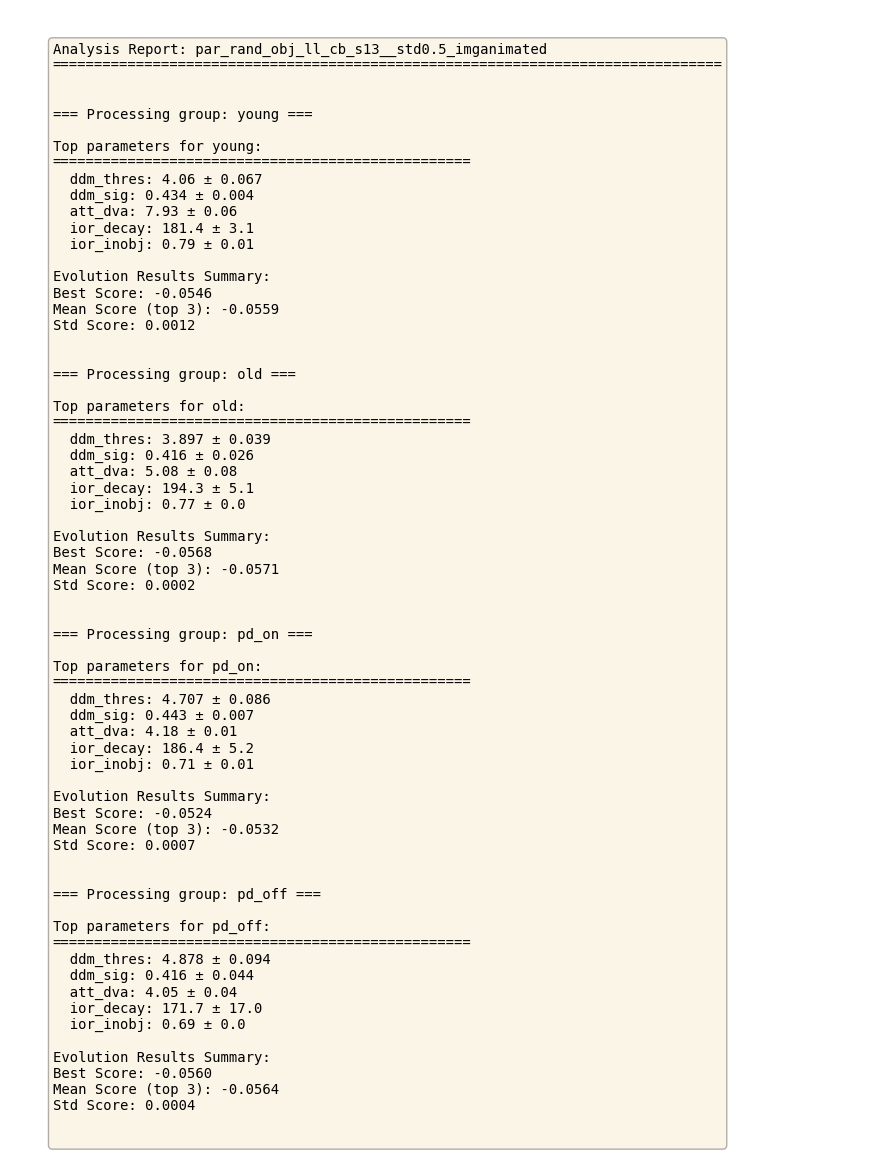

Creating foveation category comparison plot...


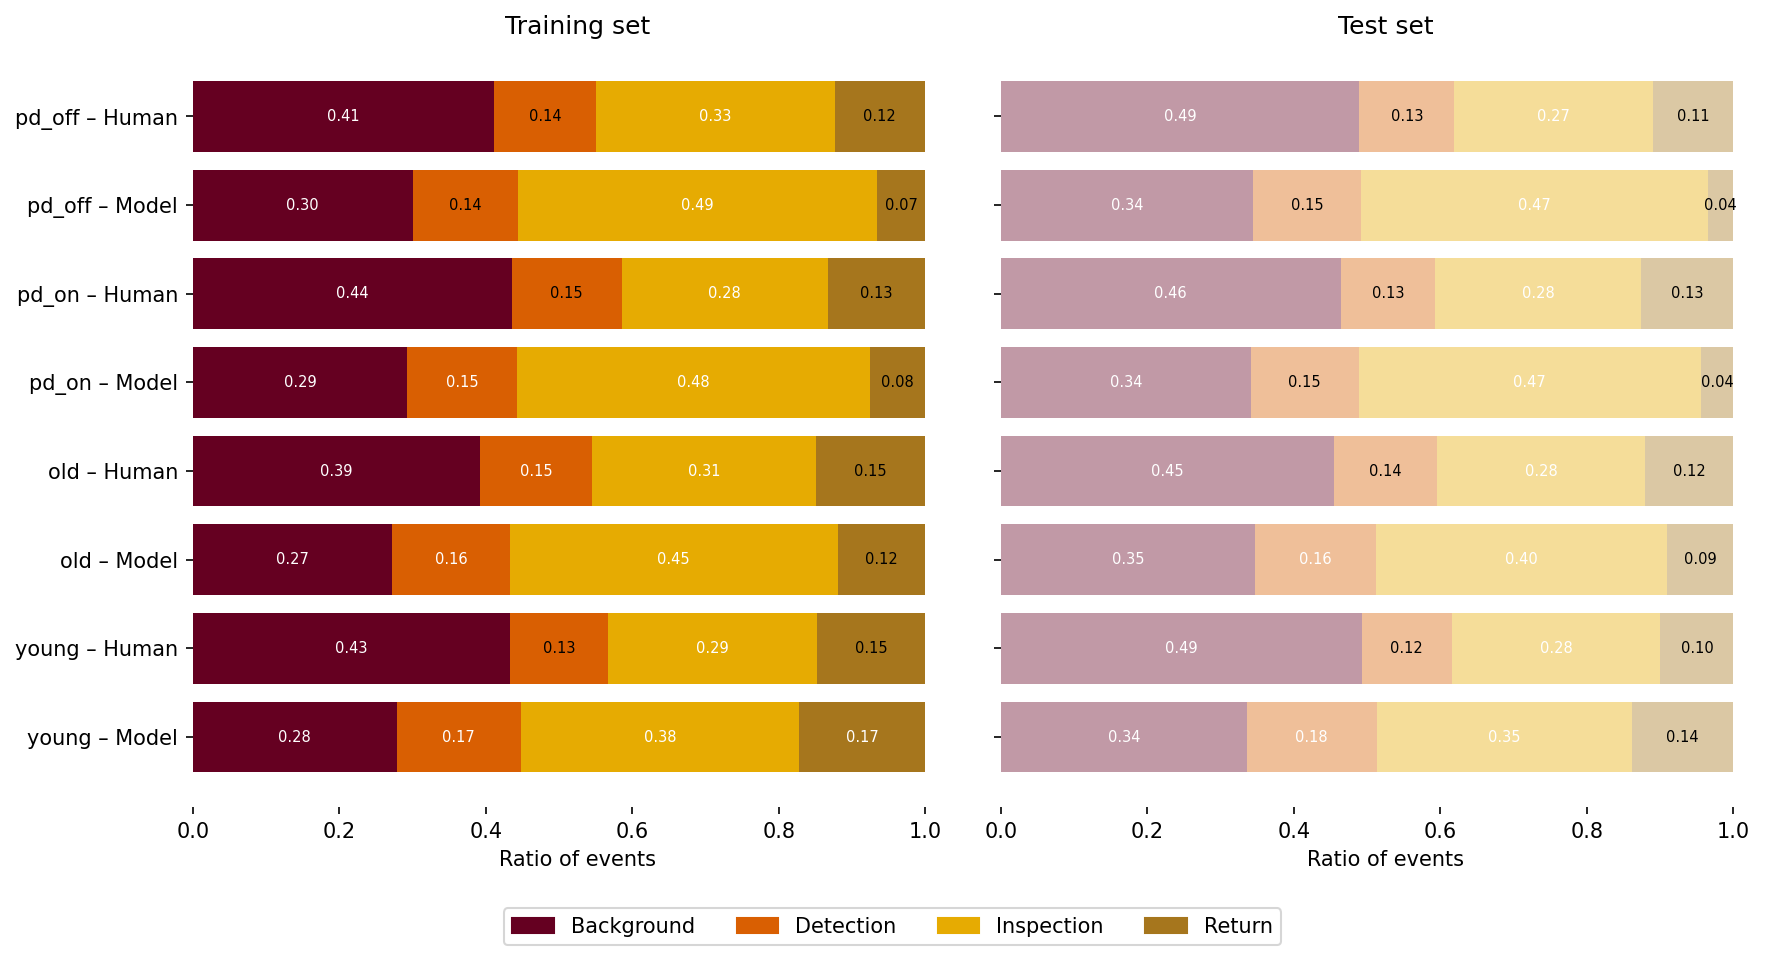

Creating BDIR timecourse plot...


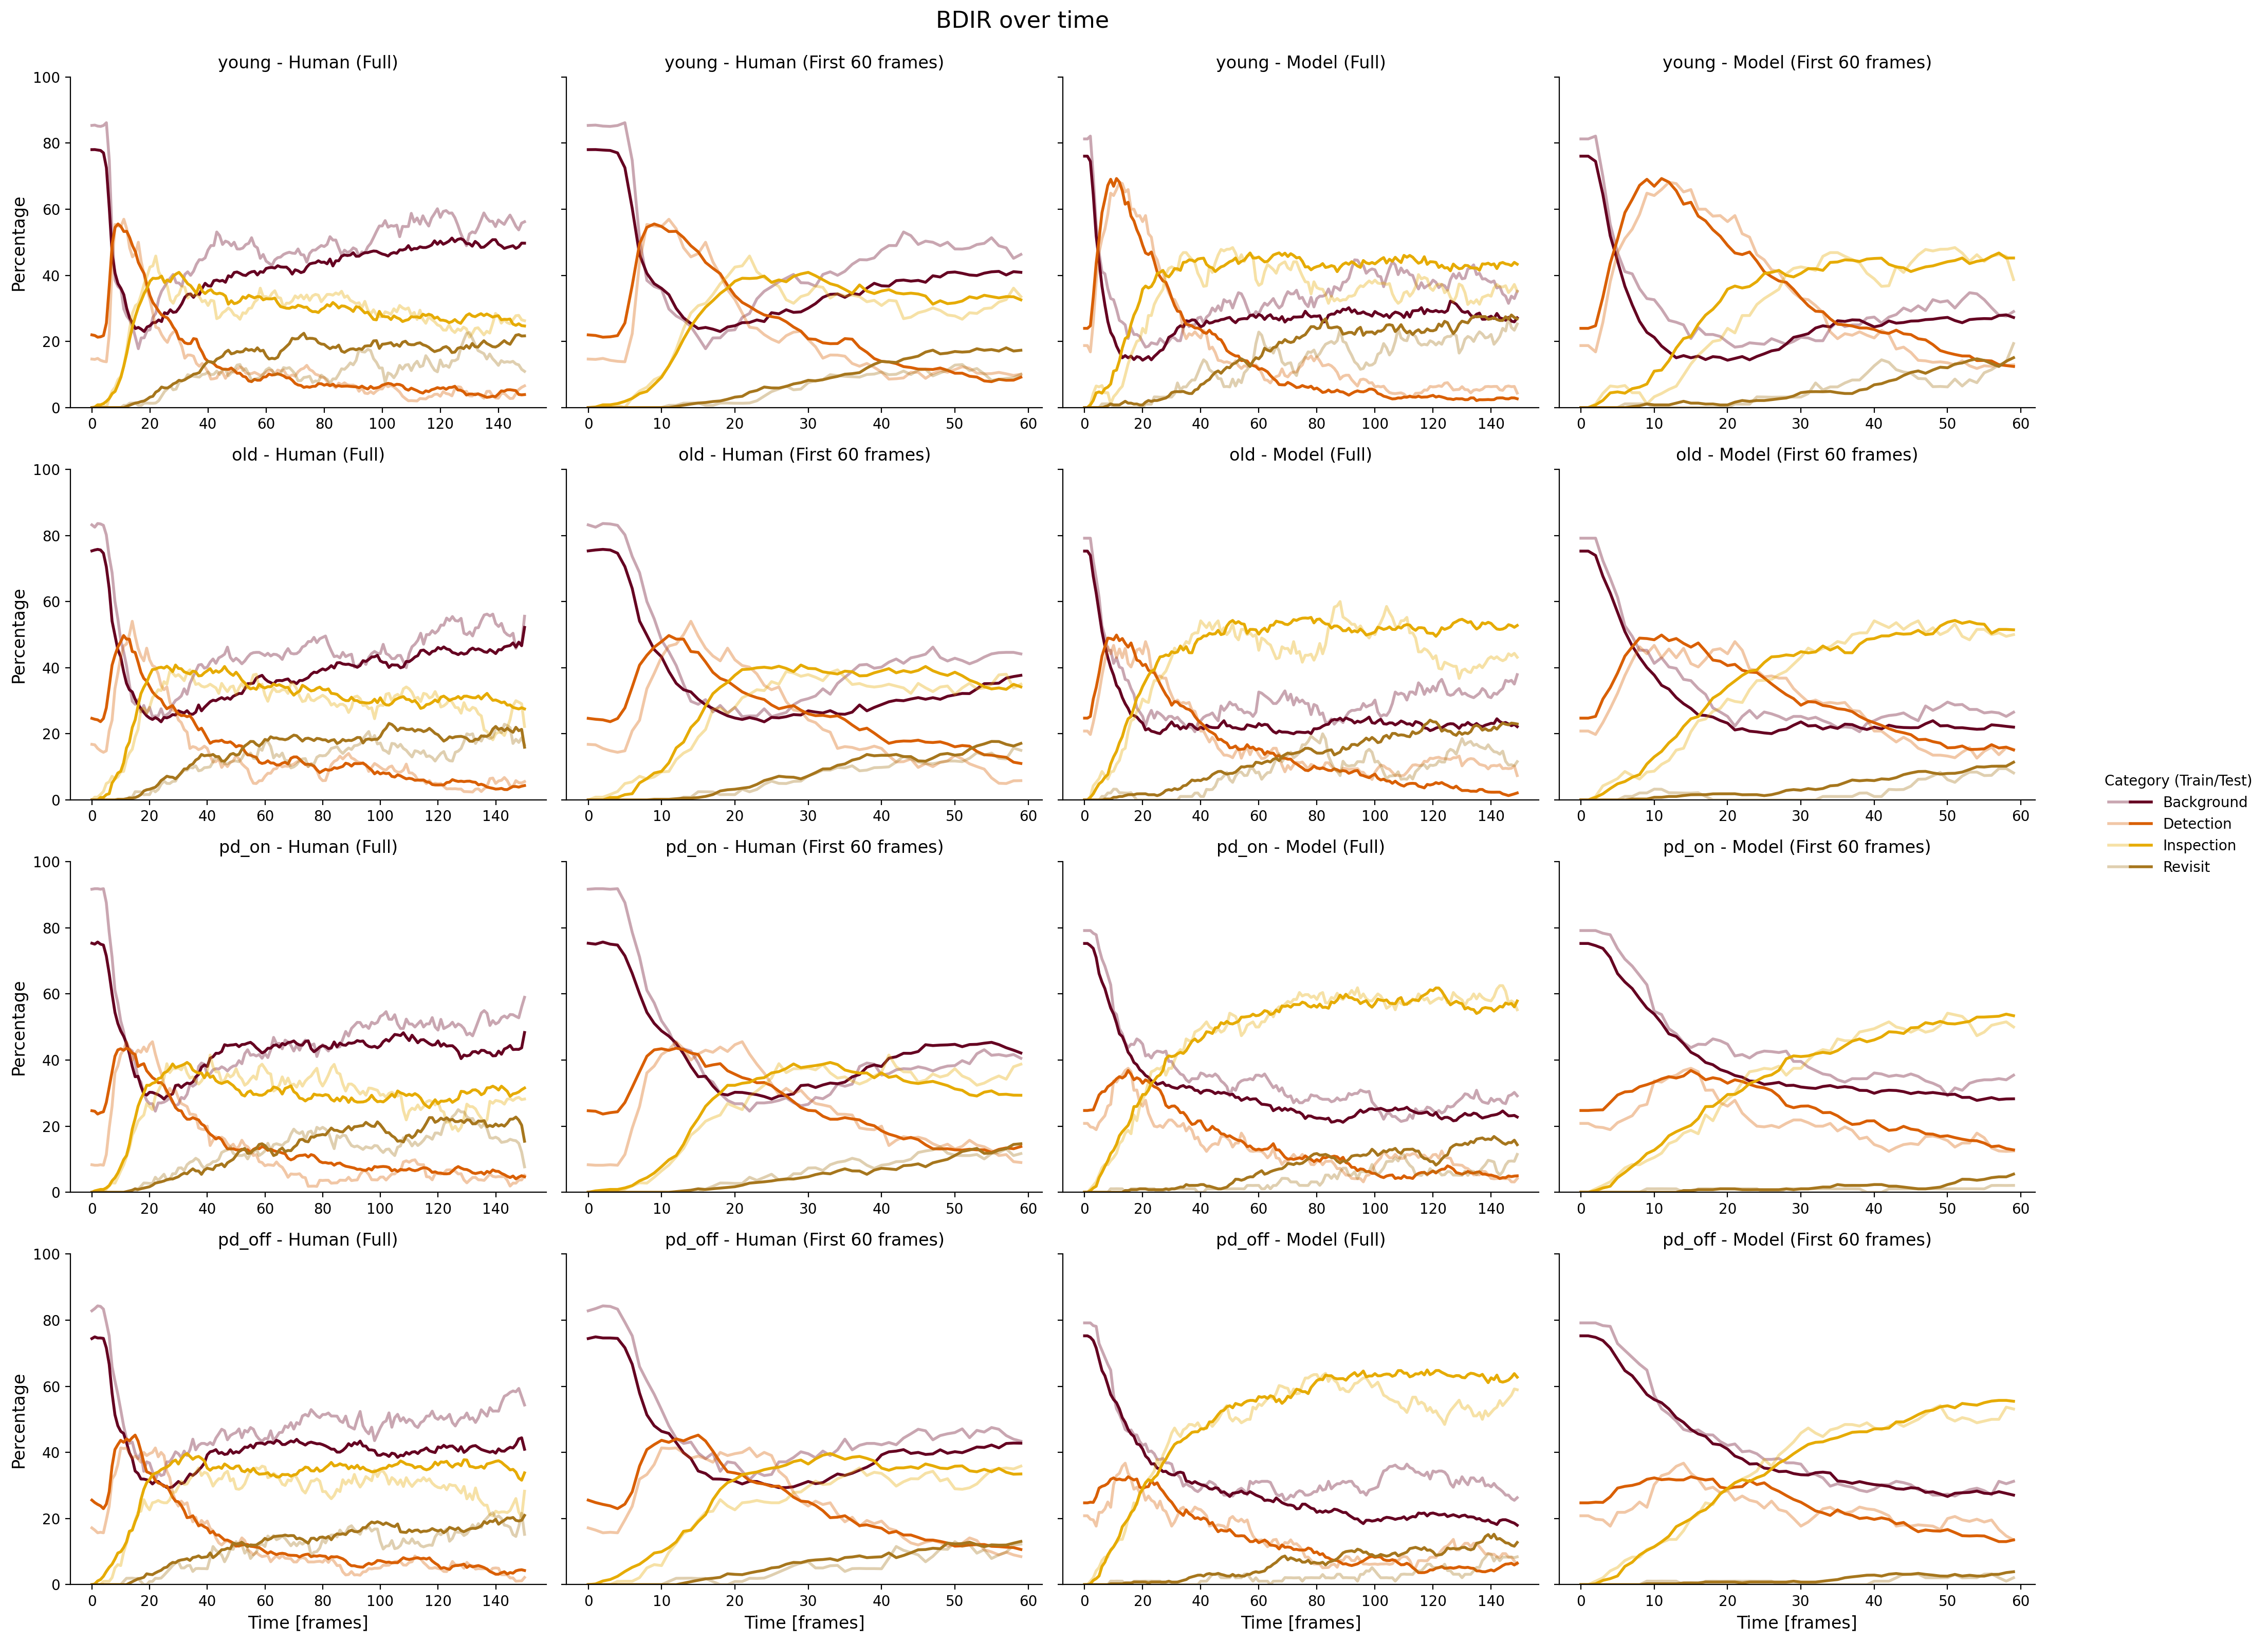

Creating BDIR violine plot...


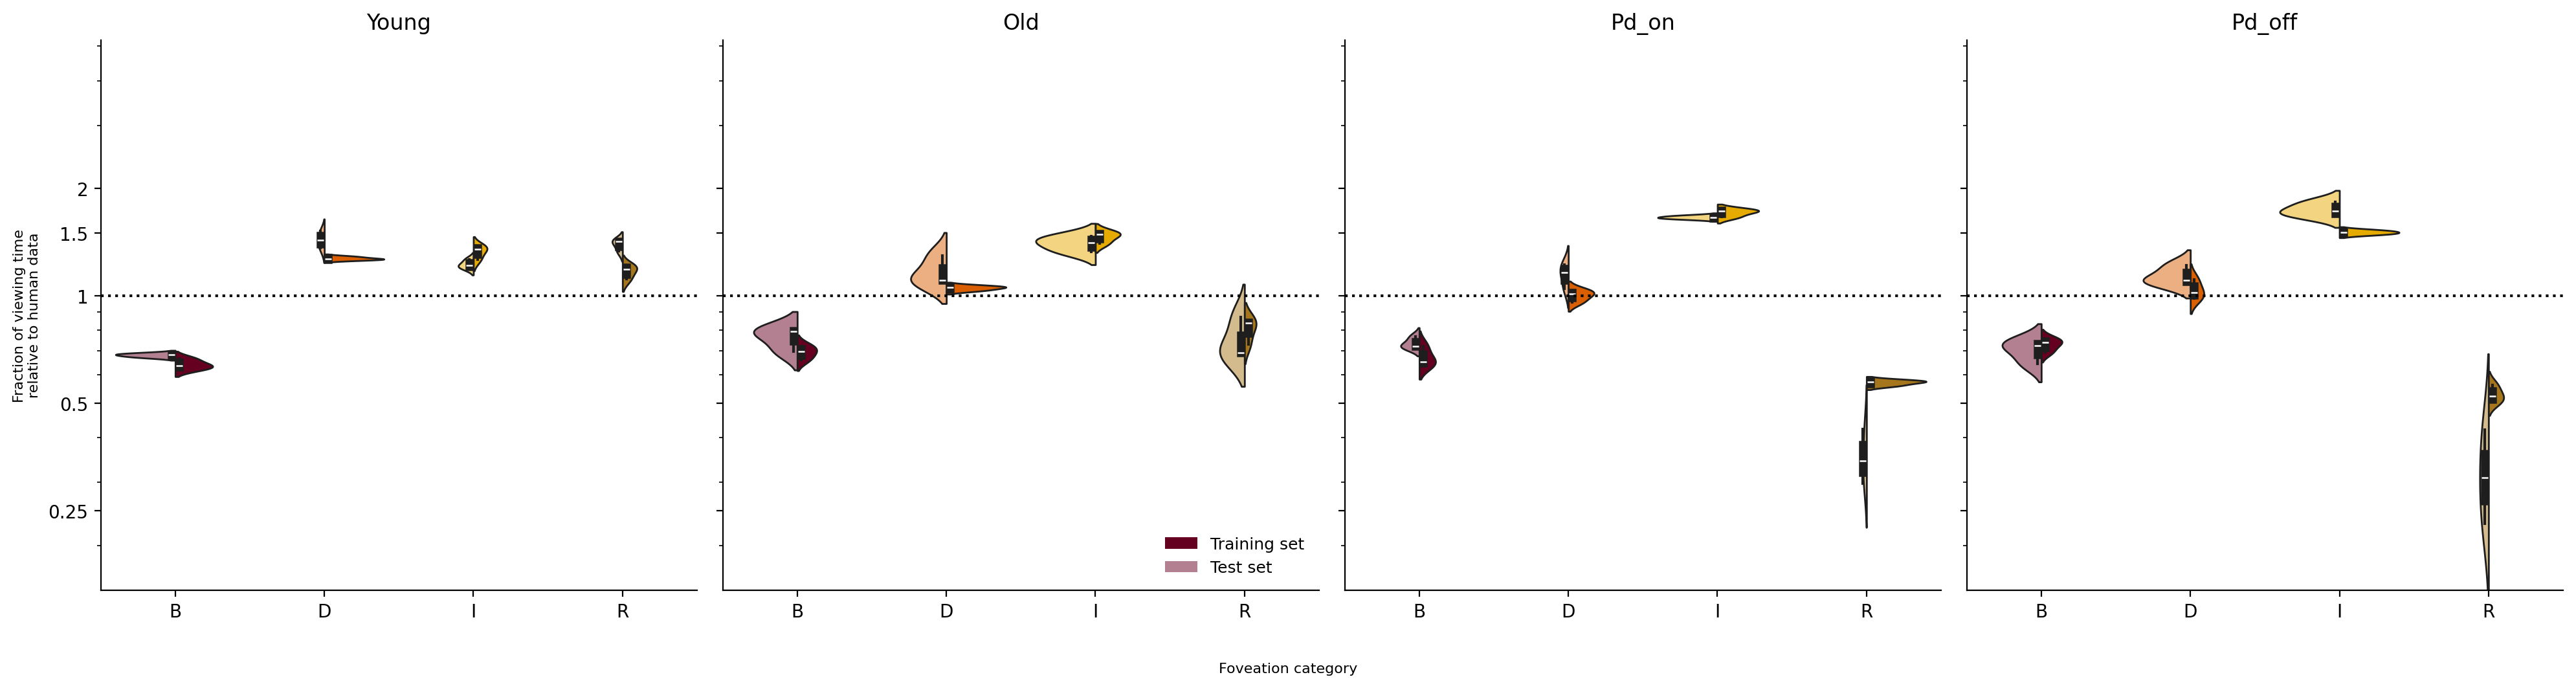

Creating detailed BDIR comparison plot...


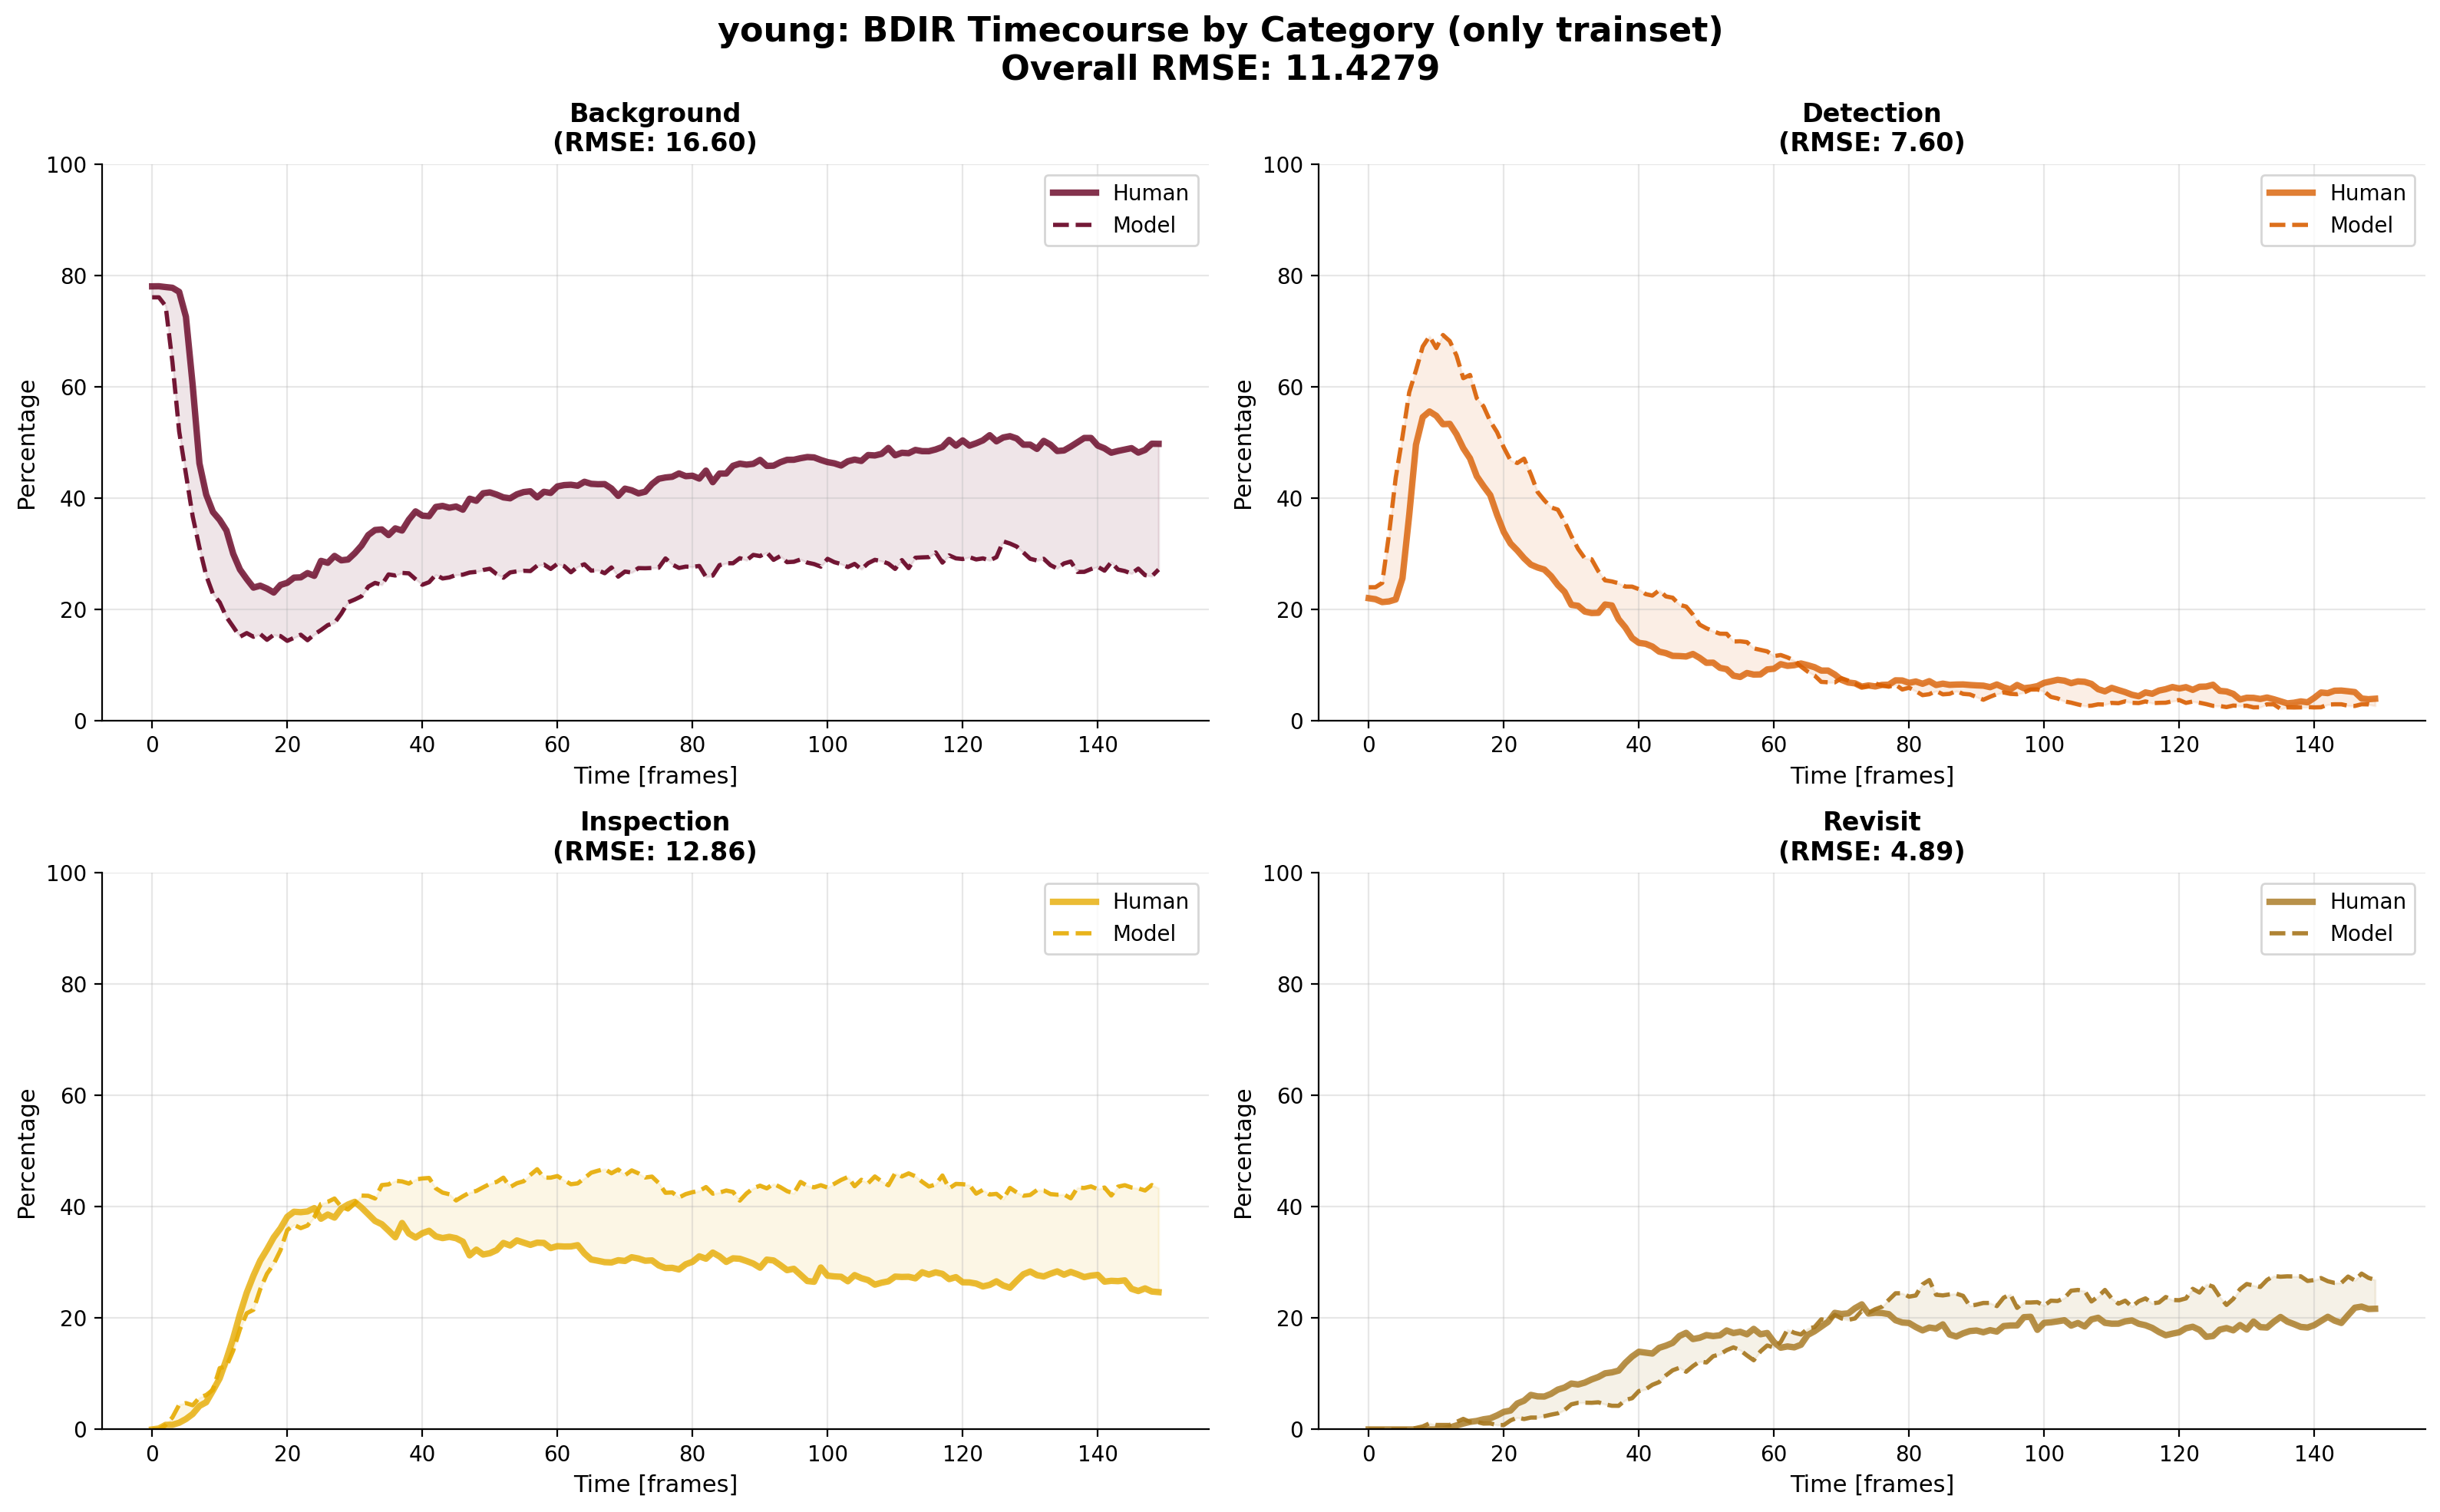

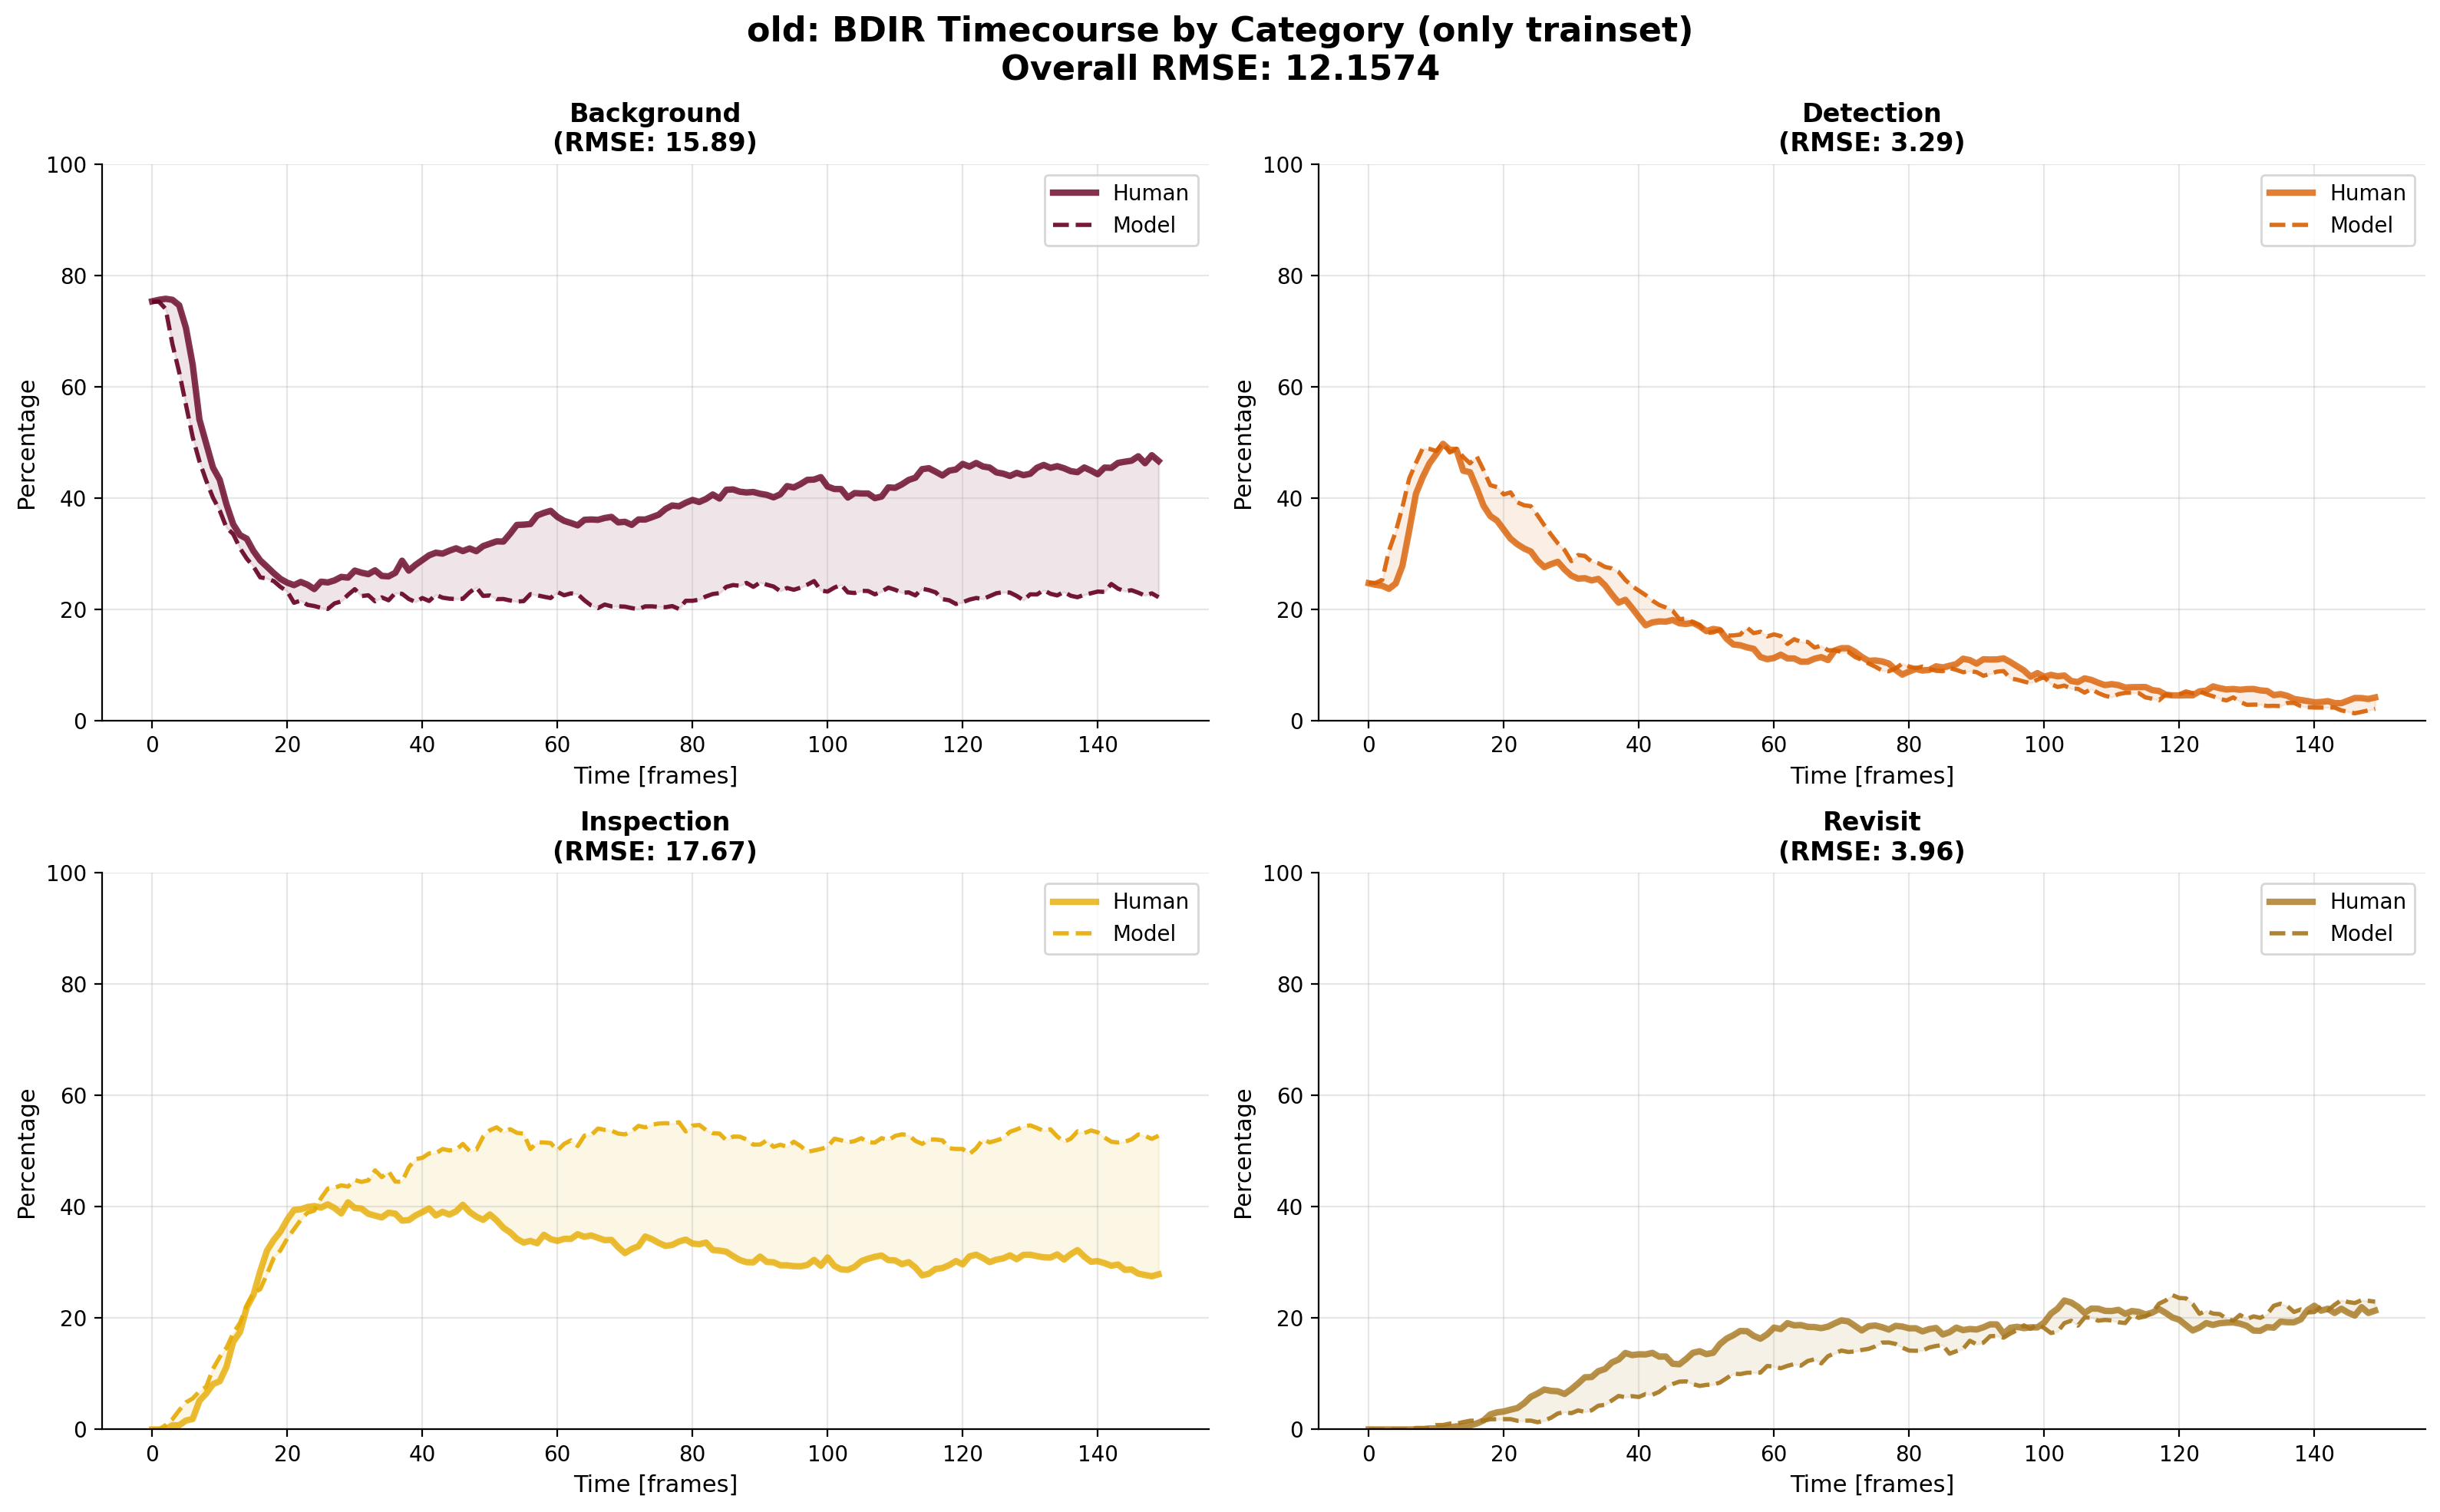

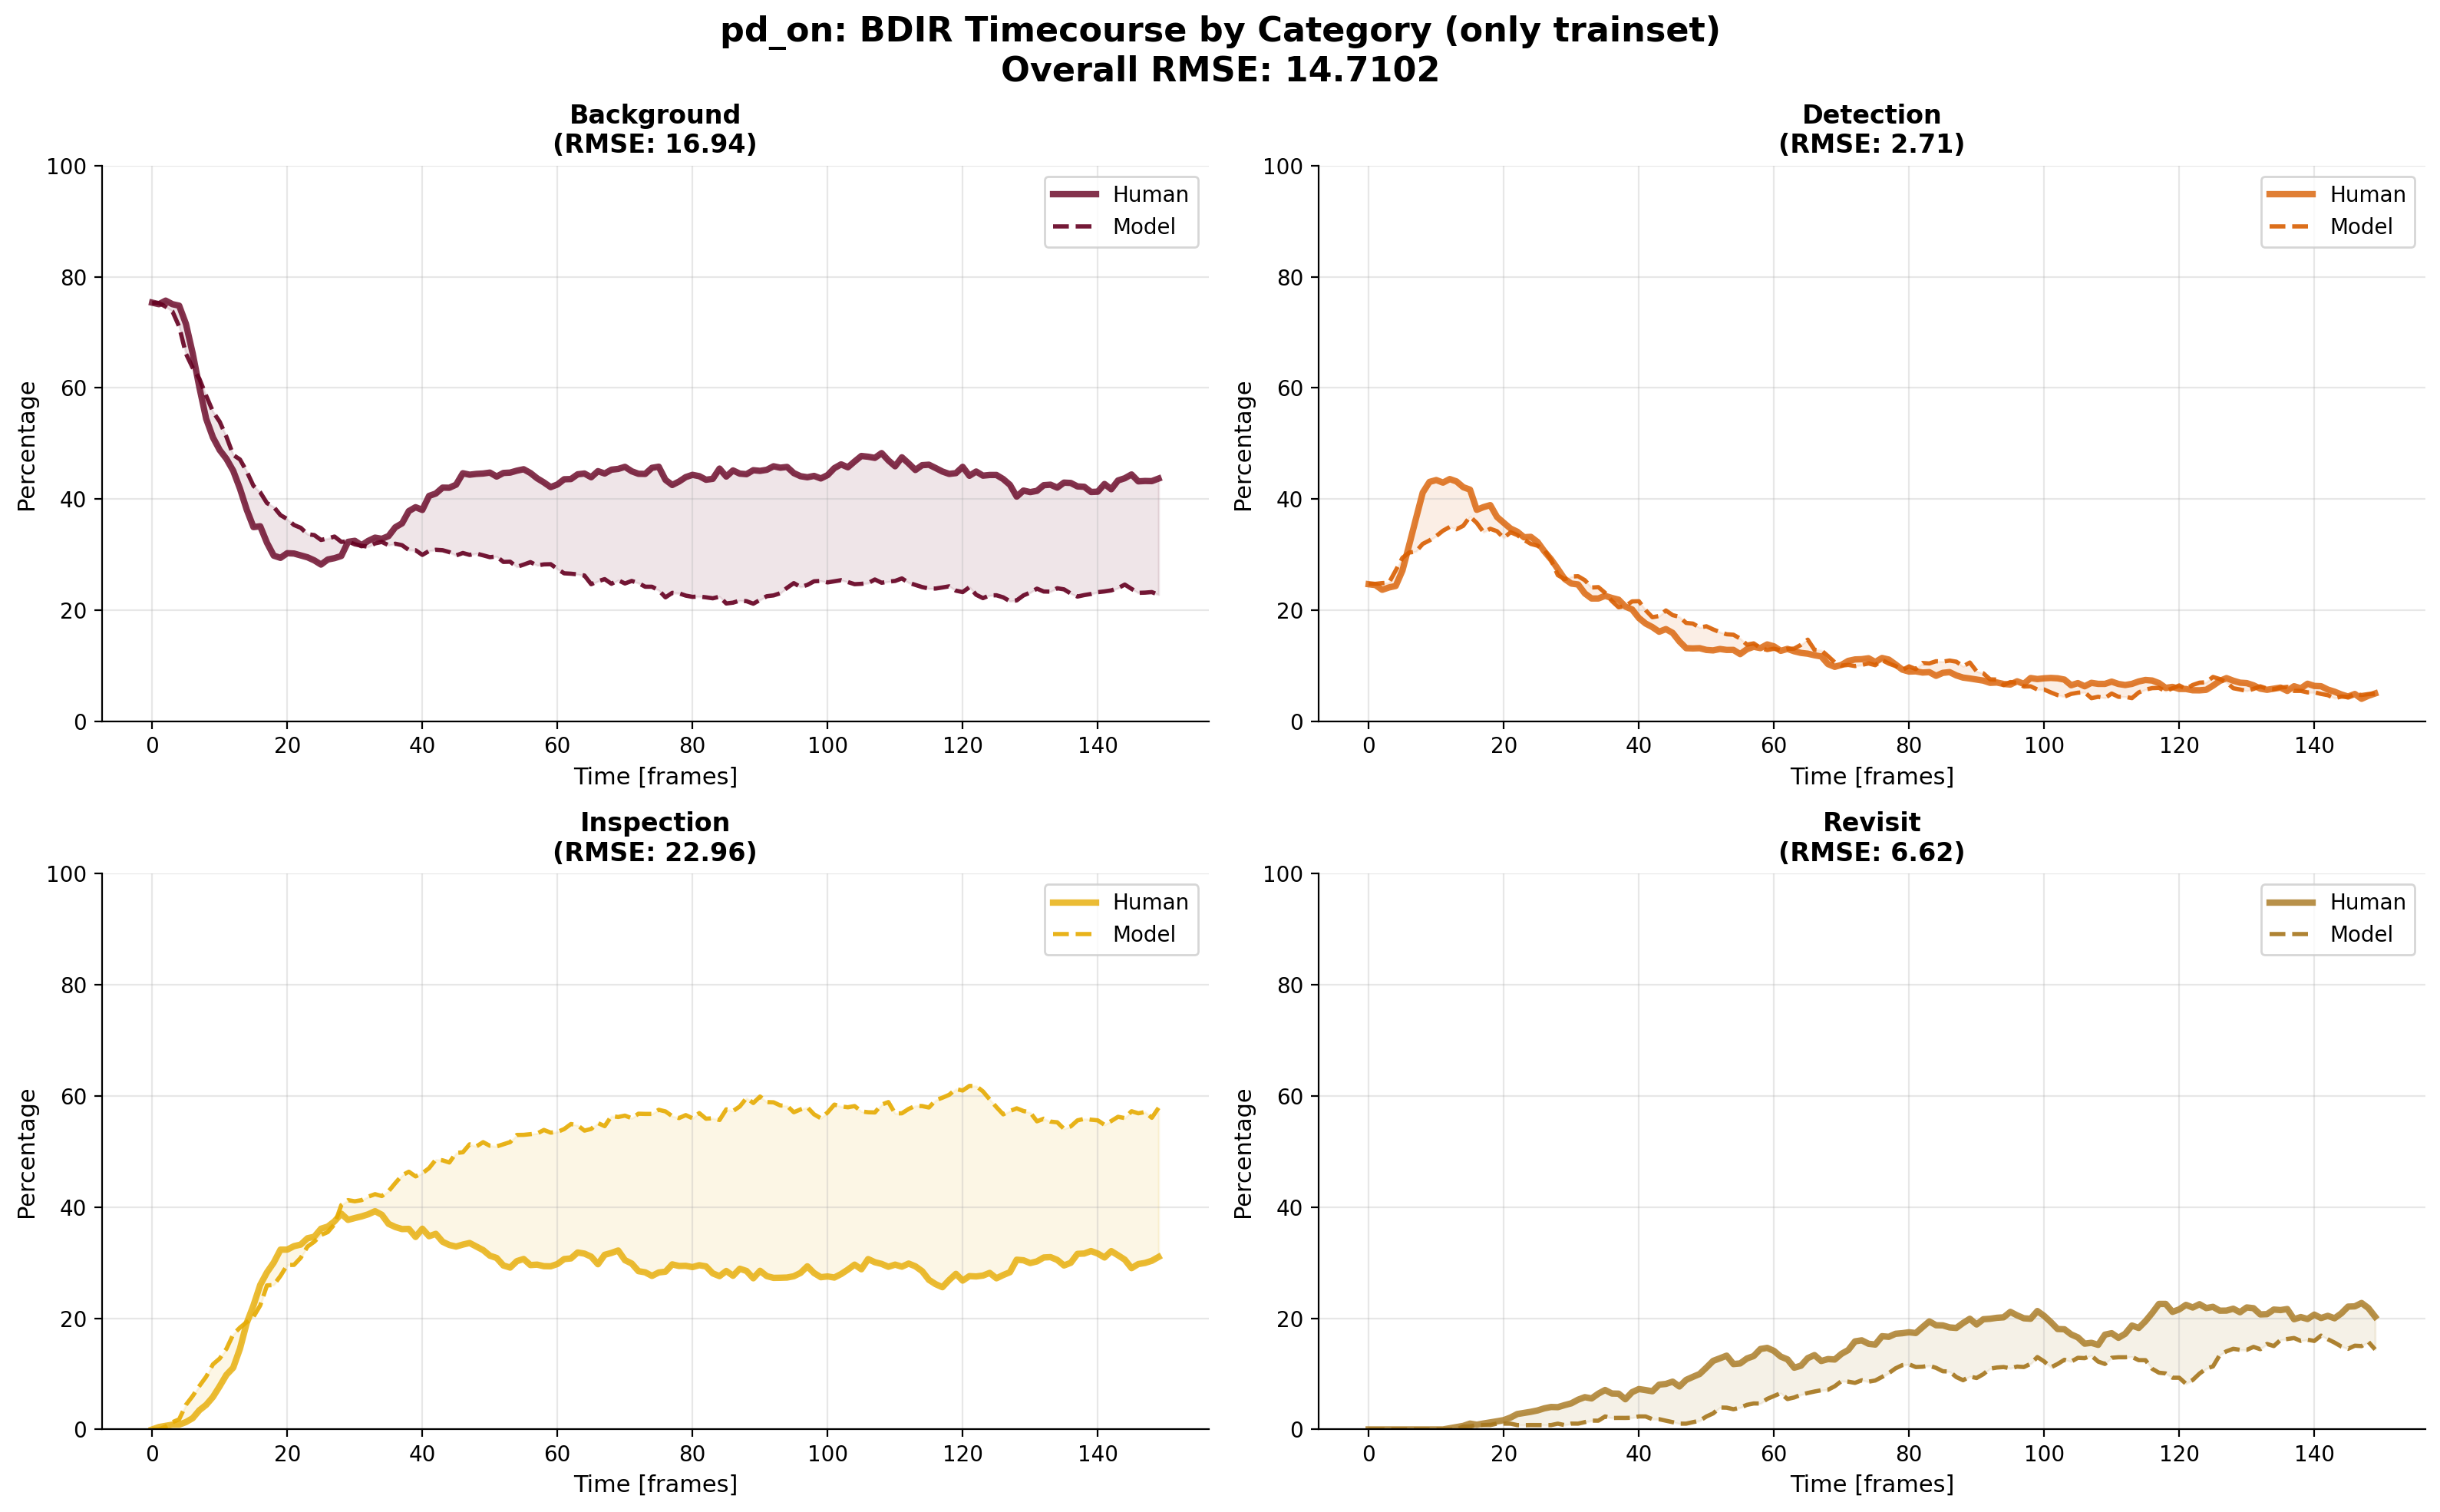

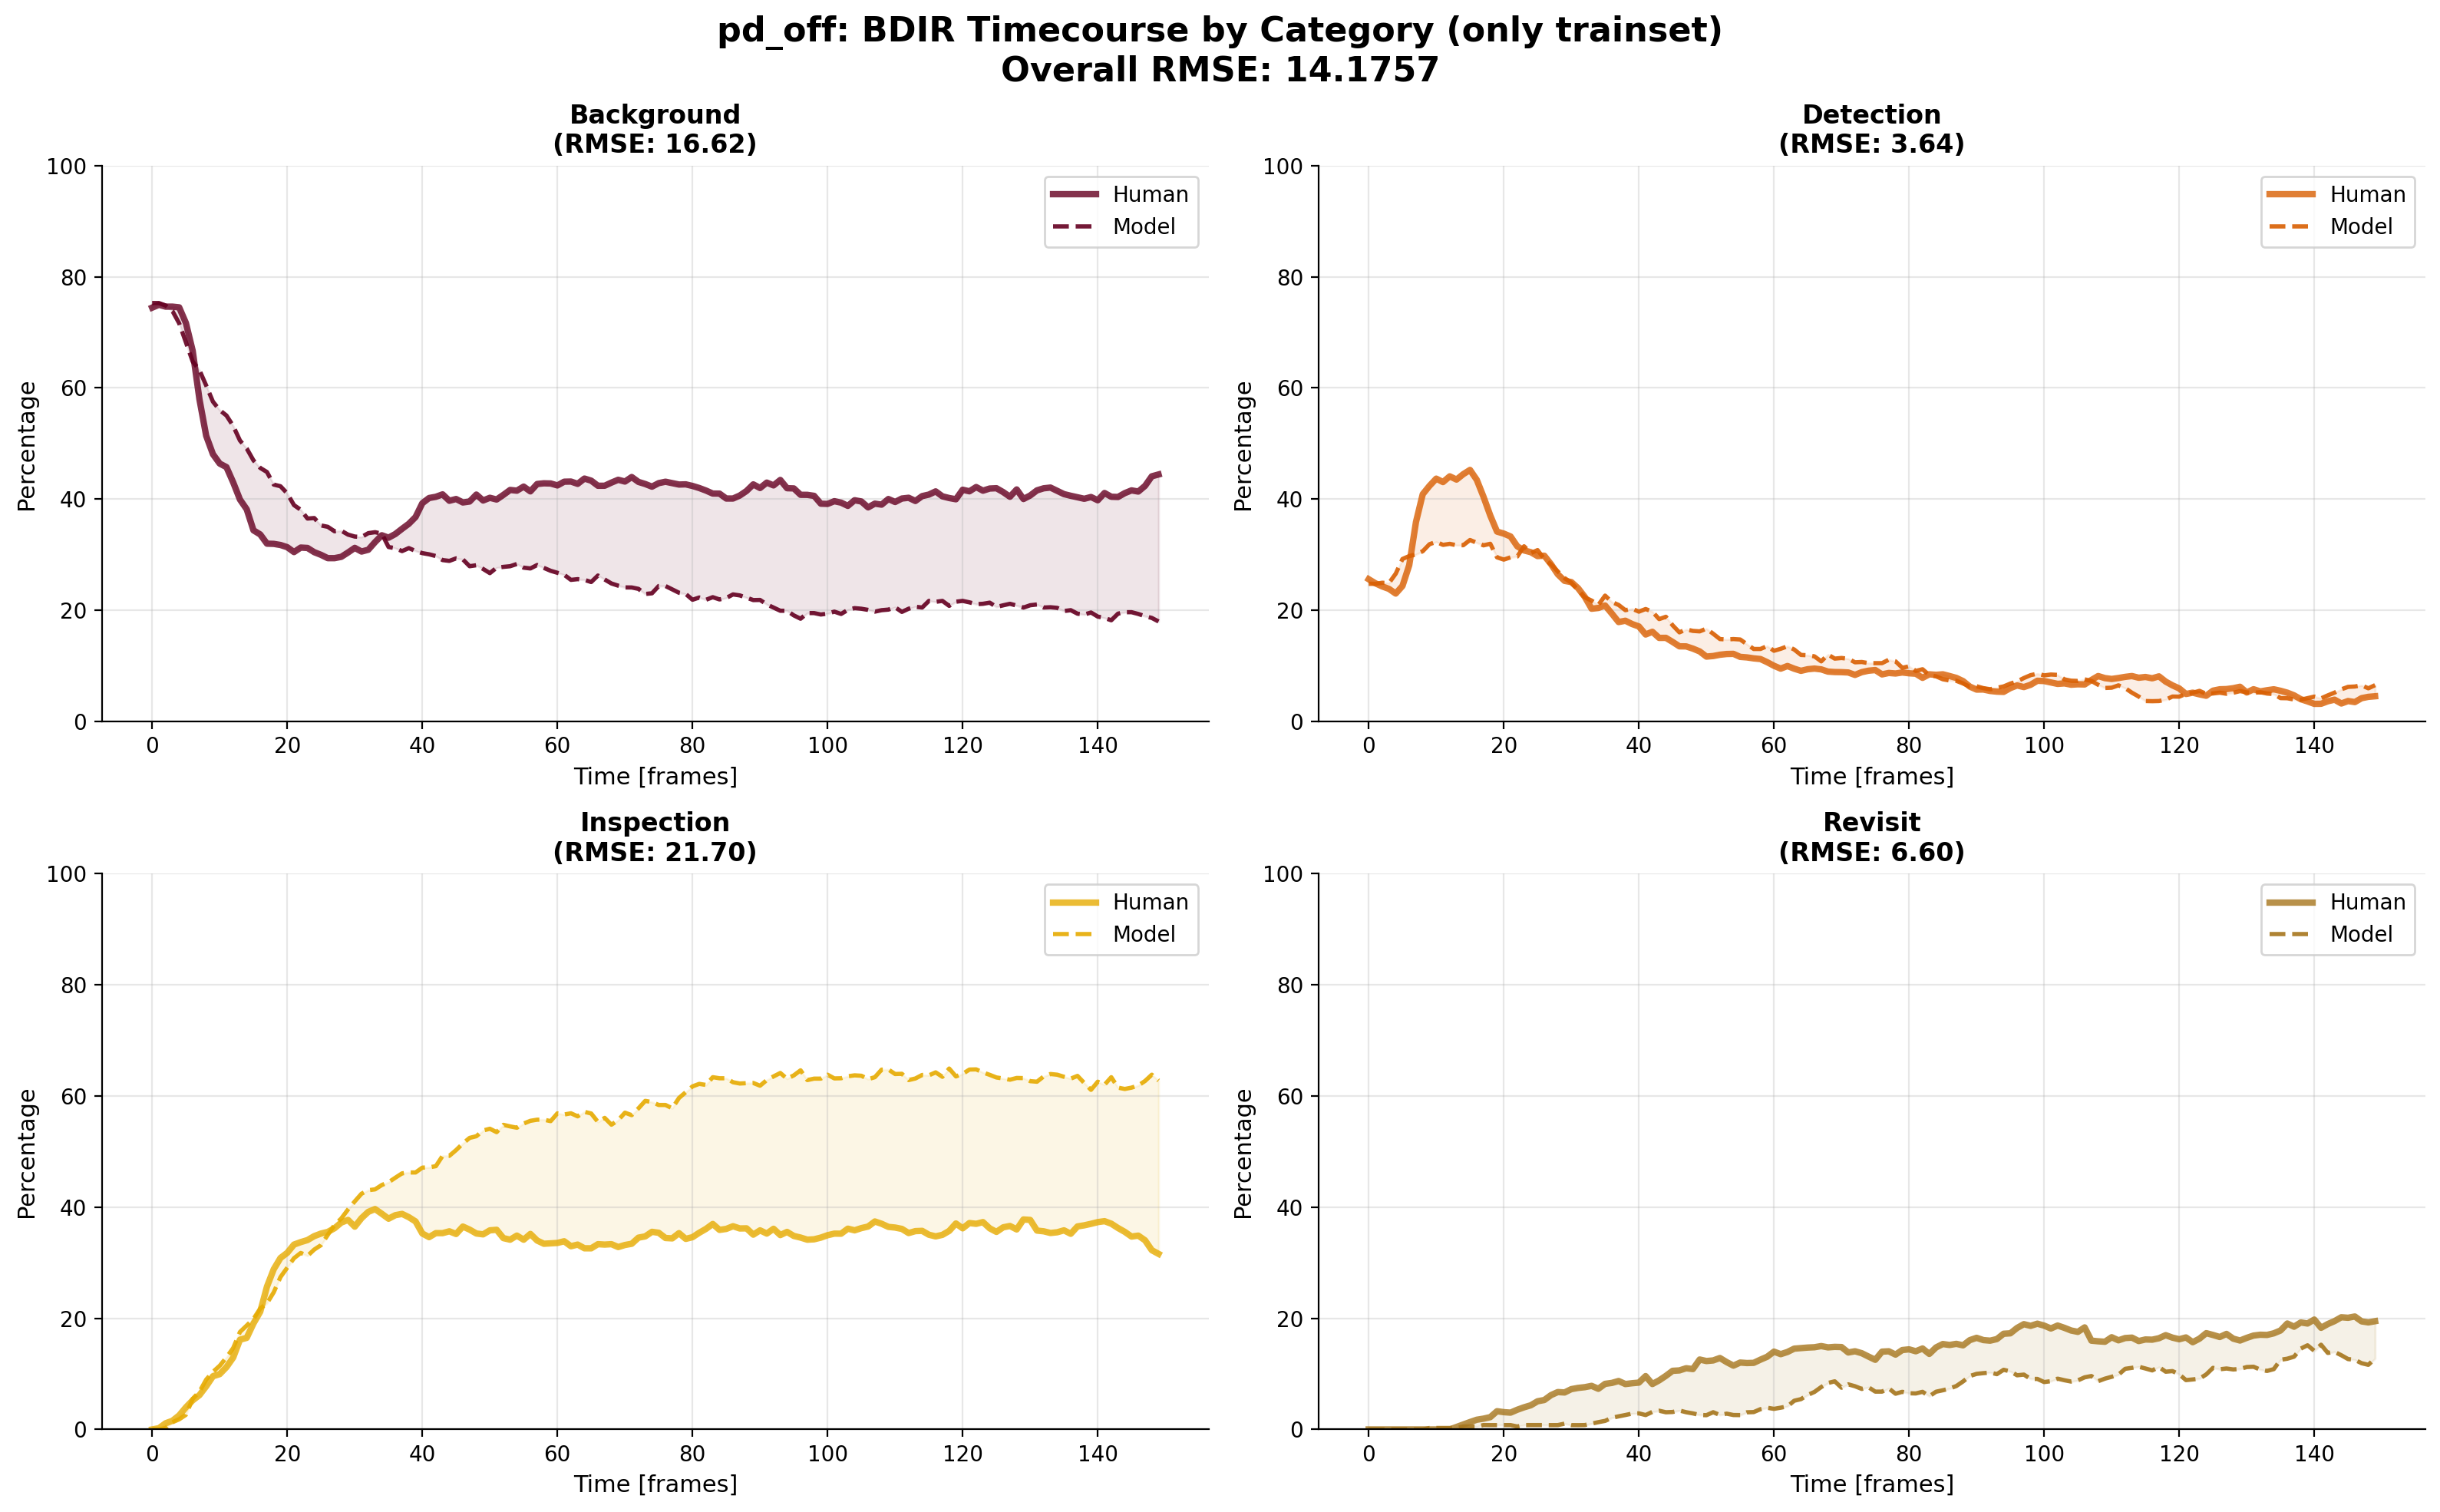

Creating object viewing plot for scene 'plank'...


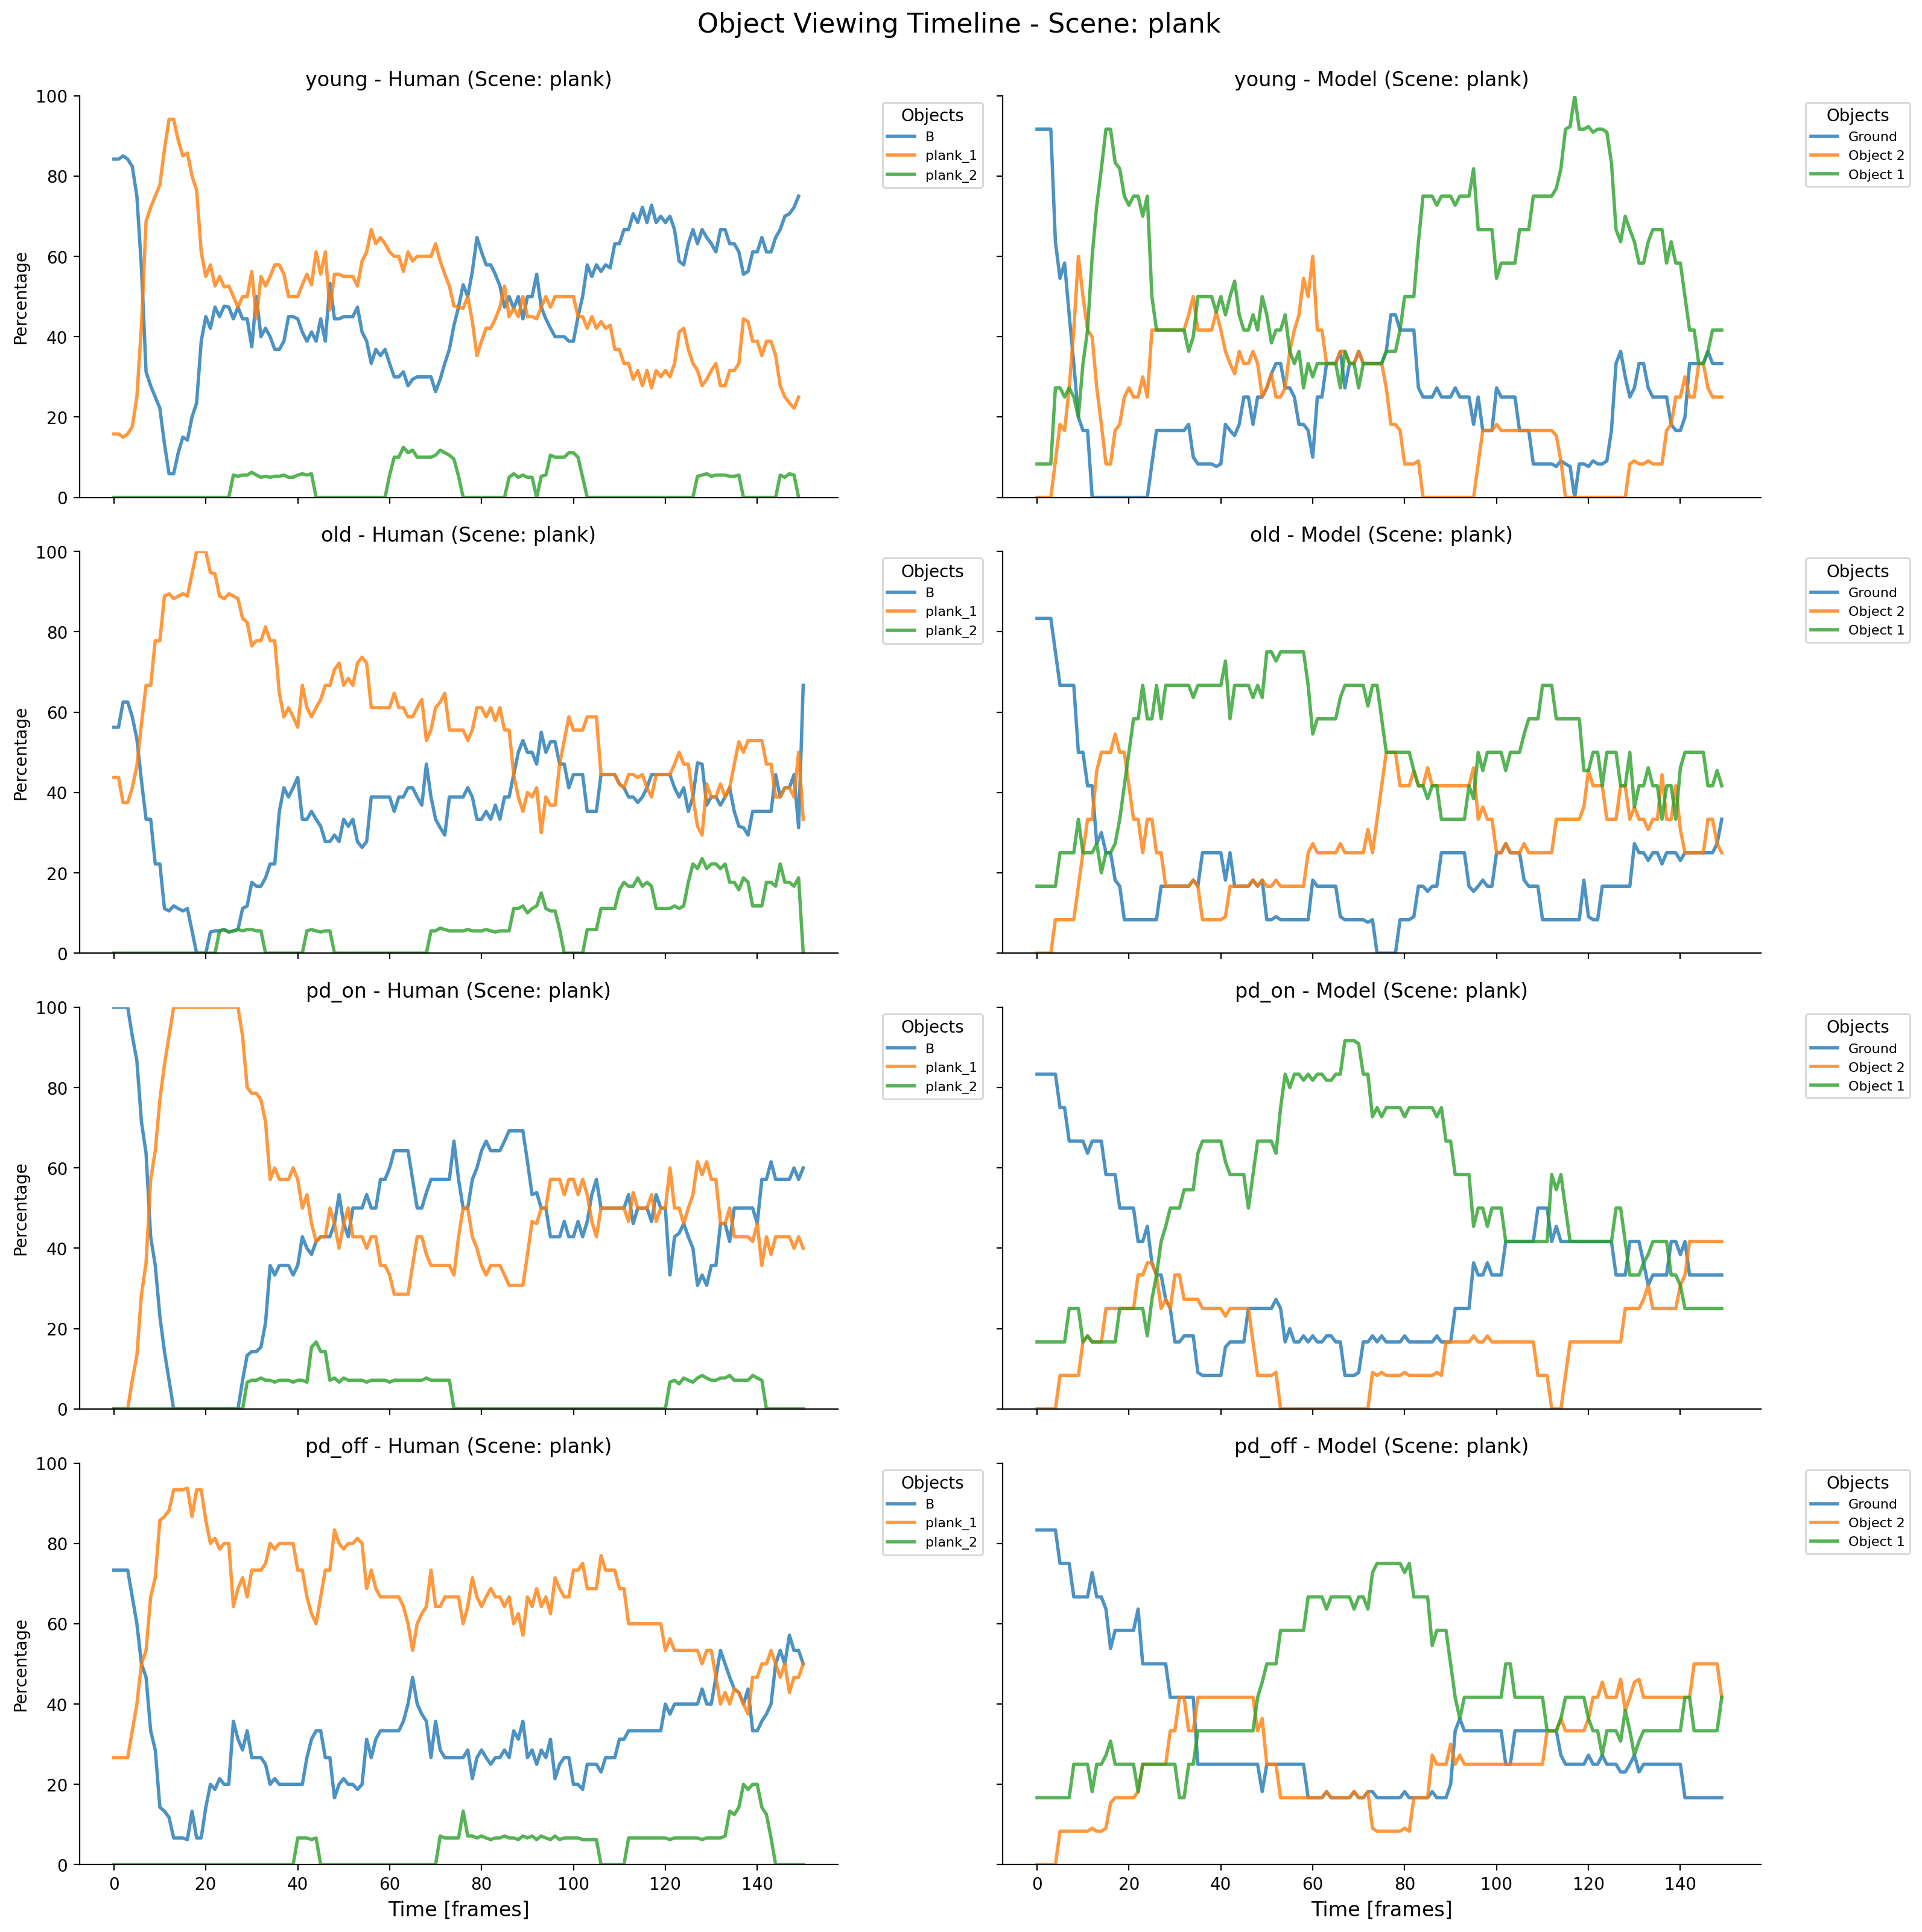

Creating Amplitude and Foveation distribution comparision ...


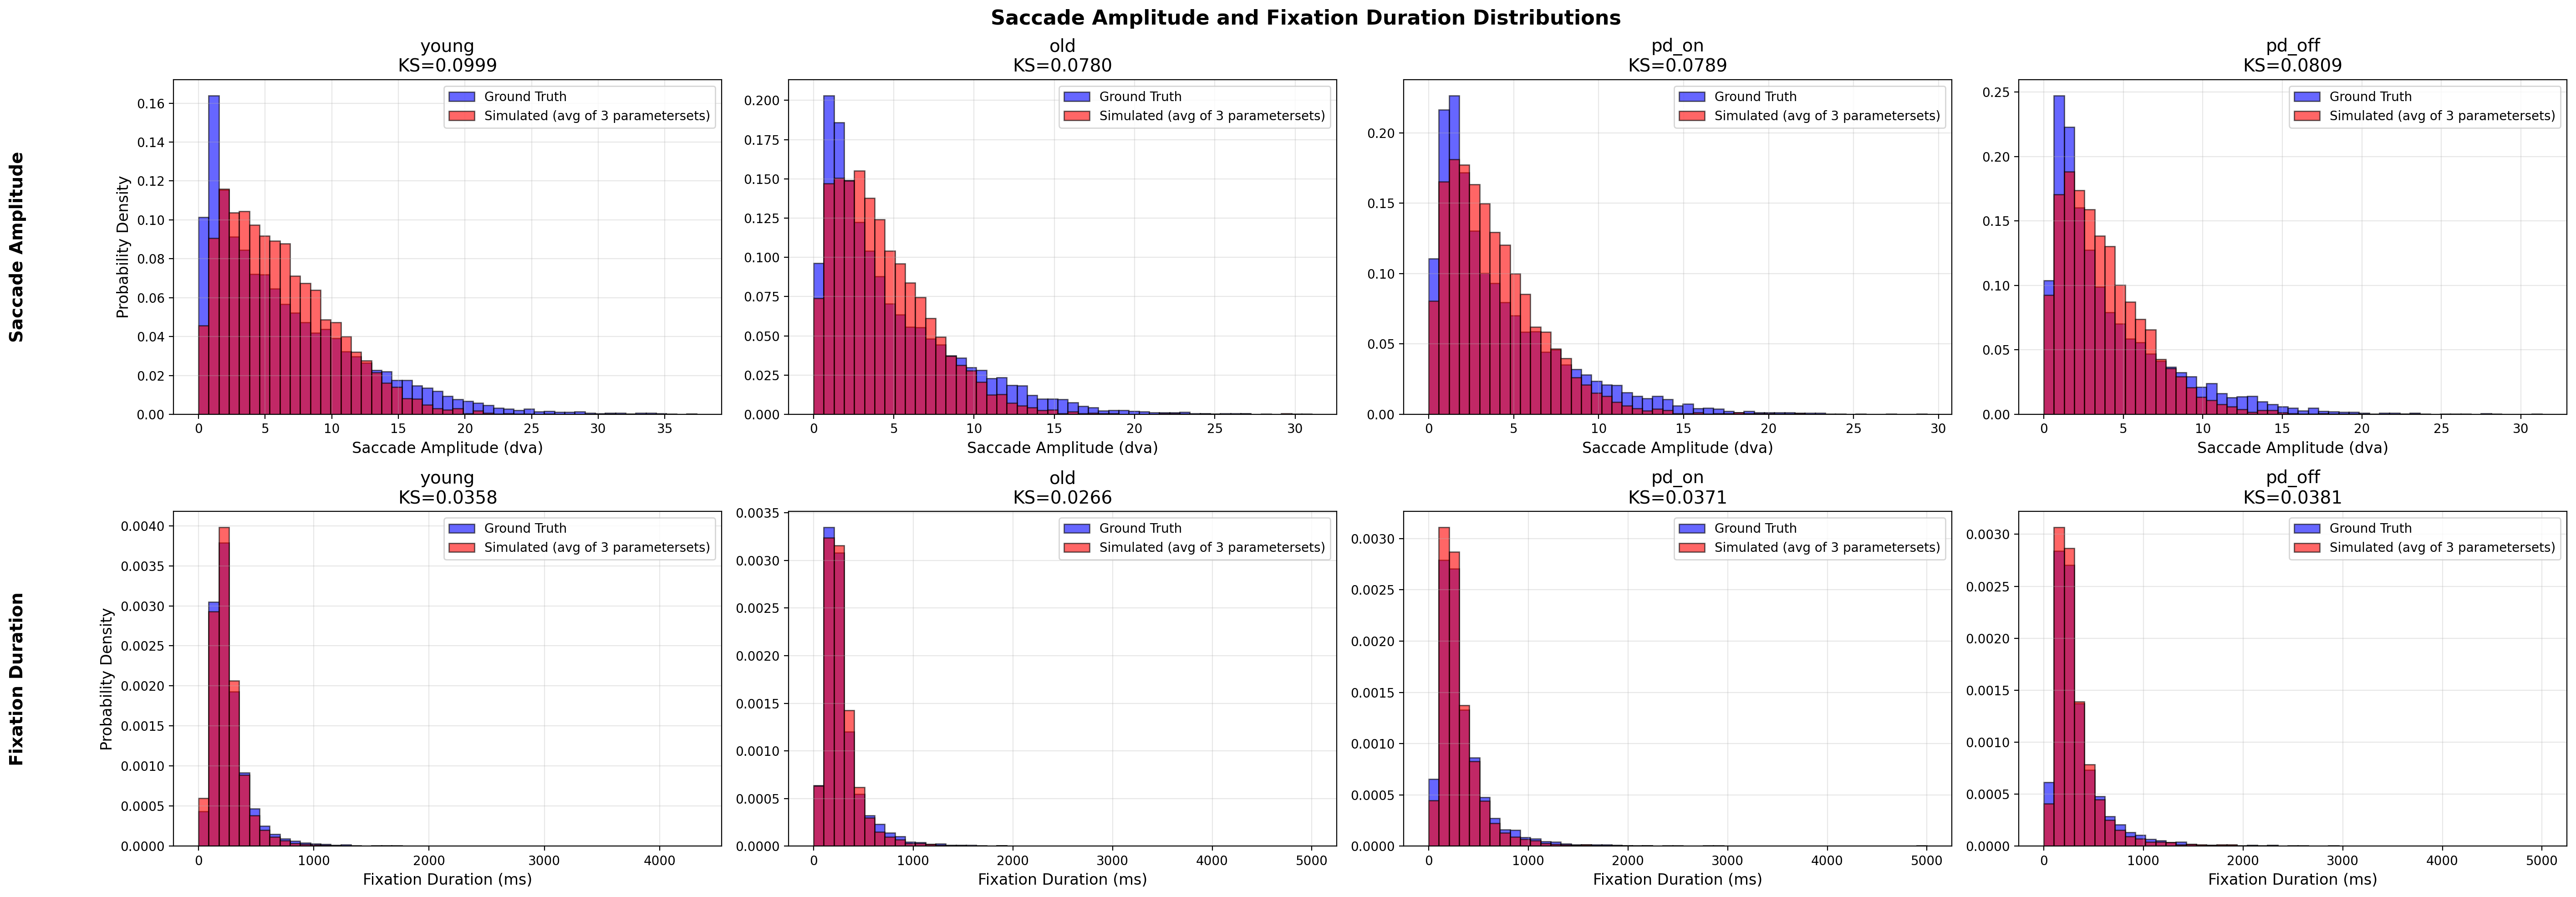


All plots and summary saved to sorted_results/bigger_trainset_scale4/analysis_report_par_rand_obj_ll_cb_s13__std0.5_imganimated_all.pdf
Initializing dataset: young
Video column is set to: scene
Initializing dataset: old
Video column is set to: scene
Initializing dataset: pd_on
Video column is set to: scene
Initializing dataset: pd_off
Video column is set to: scene

=== Processing: par_rand_obj_ll_s13__std0.5_imganimated ===

Processing group: young
Loaded evolution results for young:
      ddm_thres   ddm_sig   att_dva   ior_decay  ior_inobj     score    id  \
1286   4.267333  0.434770  8.221529  193.699925   0.774697 -0.053832  1318   
1367   4.564661  0.448828  8.366030  193.386028   0.742569 -0.054044  1399   
852    4.322136  0.423635  8.026868  192.096138   0.762455 -0.054330   884   

      gen         B         D         I         R        f0        f1  
1286   40  0.264956  0.168669  0.400591  0.165785  0.028272  0.079393  
1367   42  0.273198  0.167078  0.410041  0.149682  0.

FileNotFoundError: [Errno 2] No such file or directory: 'sorted_results/bigger_trainset_scale4/evol_par_rand_obj_ll_s13__std0.5_imganimated_old.dill'

In [33]:
#analysis_pipeline(['cb_s10__std1_imgseed10', 'obj_hl_s10__std1_imgseed10', 'obj_ll_cb_s10__std1_imgseed10', 'obj_ll_s10__std1_imgseed10'], processing_groups= ['young'], group_naming='young')
#analysis_pipeline(['not05_cb_s13__std0.8_imgseed10'],  processing_groups= ['old', 'pd_on', 'pd_off'], group_naming='all')
analysis_pipeline(['par_rand_obj_ll_cb_s13__std0.5_imganimated', 'par_rand_obj_ll_s13__std0.5_imganimated', 
 'par_rand_cb_s13__std0.5_imganimated',
 'par_rand_obj_hl_s13__std0.5_imganimated'], processing_groups= ['young', 'old', 'pd_on', 'pd_off'], group_naming='all')

--------------------------------

# Additional Analysis

### Checking distribution fitting

Loading ground truth data from: /mnt/raid/data/anina/ScanDy/PictureExample/PictureExample_Resized/parkinson_data/df_img_fovs_psycsci.csv
Ground truth saccade amplitudes: n=22991, mean=6.51, median=4.86
Ground truth durations: n=24591, mean=262.68, median=218.00

Loading simulated data from: /mnt/raid/data/anina/ScanDy/sorted_results/overfitting/best_cb_s13__std0.8_imgseed10_young_1.csv.gz
Simulated saccade amplitudes: n=3748, mean=6.31, median=5.82
Simulated durations: n=3976, mean=248.92, median=225.16

KS Statistics:
  Amplitude: KS=0.1611, p=1.5292e-73
  Duration:  KS=0.0396, p=4.2097e-05

DETAILED STATISTICS

Ground Truth Amplitude:
  Mean: 6.51 dva
  Median: 4.86 dva
  Std: 5.67 dva
  Min: 0.02 dva
  Max: 37.39 dva
  25th percentile: 1.97 dva
  75th percentile: 9.58 dva

Simulated Amplitude:
  Mean: 6.31 dva
  Median: 5.82 dva
  Std: 3.64 dva
  Min: 0.08 dva
  Max: 22.56 dva
  25th percentile: 3.49 dva
  75th percentile: 8.64 dva

  Difference in means: -0.20 dva
  Ratio of means:

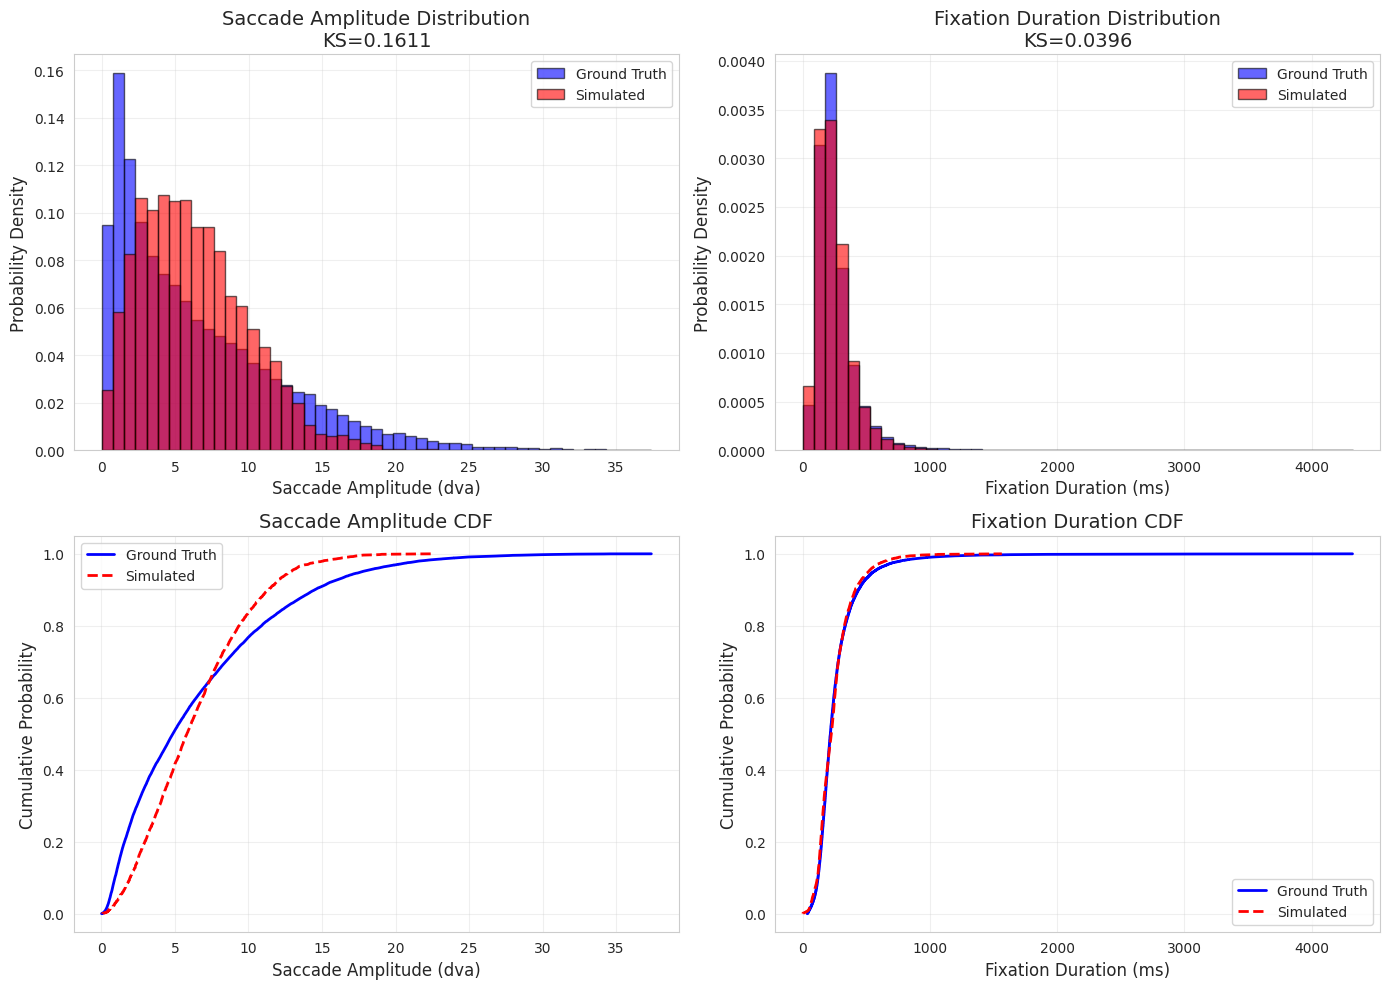

In [41]:
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
# ============ PARAMETERS ============

simulate_file = f"/mnt/raid/data/anina/ScanDy/sorted_results/overfitting/best_cb_s13__std0.8_imgseed10_young_1.csv.gz"
test_group = 'young' 
dataframe_files = {
    "young": '/mnt/raid/data/anina/ScanDy/PictureExample/PictureExample_Resized/parkinson_data/df_img_fovs_psycsci.csv',
}

print(f"Loading ground truth data from: {dataframe_files[test_group]}")
gt_df = pd.read_csv(dataframe_files[test_group])

gt_amp_dva = gt_df["sac_amp_dva"].dropna().values
# gt_amp_dva = gt_amp_dva[gt_amp_dva > 0.5]  # only saccades larger than 0.5 dva
gt_dur_ms = gt_df["duration_ms"].dropna().values


print(f"Ground truth saccade amplitudes: n={len(gt_amp_dva)}, mean={gt_amp_dva.mean():.2f}, median={np.median(gt_amp_dva):.2f}")
print(f"Ground truth durations: n={len(gt_dur_ms)}, mean={gt_dur_ms.mean():.2f}, median={np.median(gt_dur_ms):.2f}")

# ============ LOAD SIMULATED DATA ============
# Try to load from the best parameter simulation (rank 0)

if os.path.exists(simulate_file):
    print(f"\nLoading simulated data from: {simulate_file}")
    sim_df = pd.read_csv(simulate_file, compression='gzip')
    
    sim_amp_dva = sim_df["sac_amp_dva"].dropna().values
    sim_dur_ms = sim_df["duration_ms"].dropna().values
    
    print(f"Simulated saccade amplitudes: n={len(sim_amp_dva)}, mean={sim_amp_dva.mean():.2f}, median={np.median(sim_amp_dva):.2f}")
    print(f"Simulated durations: n={len(sim_dur_ms)}, mean={sim_dur_ms.mean():.2f}, median={np.median(sim_dur_ms):.2f}")
    
    # Calculate KS statistics
    ks_amp, p_amp = stats.ks_2samp(gt_amp_dva, sim_amp_dva)
    ks_dur, p_dur = stats.ks_2samp(gt_dur_ms, sim_dur_ms)
    
    print(f"\nKS Statistics:")
    print(f"  Amplitude: KS={ks_amp:.4f}, p={p_amp:.4e}")
    print(f"  Duration:  KS={ks_dur:.4f}, p={p_dur:.4e}")
    
else:
    print(f"Simulated data file not found: {simulate_file}")
    

# ============ CREATE PLOTS ============
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Amplitude Histogram
ax = axes[0, 0]
bins_amp = np.linspace(0, max(gt_amp_dva.max(), sim_amp_dva.max() if sim_df is not None else gt_amp_dva.max()), 50)
ax.hist(gt_amp_dva, bins=bins_amp, alpha=0.6, label='Ground Truth', density=True, color='blue', edgecolor='black')
if sim_df is not None:
    ax.hist(sim_amp_dva, bins=bins_amp, alpha=0.6, label='Simulated', density=True, color='red', edgecolor='black')
ax.set_xlabel('Saccade Amplitude (dva)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(f'Saccade Amplitude Distribution\nKS={ks_amp:.4f}' if sim_df is not None else 'Saccade Amplitude Distribution', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Duration Histogram
ax = axes[0, 1]
bins_dur = np.linspace(0, max(gt_dur_ms.max(), sim_dur_ms.max() if sim_df is not None else gt_dur_ms.max()), 50)
ax.hist(gt_dur_ms, bins=bins_dur, alpha=0.6, label='Ground Truth', density=True, color='blue', edgecolor='black')
if sim_df is not None:
    ax.hist(sim_dur_ms, bins=bins_dur, alpha=0.6, label='Simulated', density=True, color='red', edgecolor='black')
ax.set_xlabel('Fixation Duration (ms)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(f'Fixation Duration Distribution\nKS={ks_dur:.4f}' if sim_df is not None else 'Fixation Duration Distribution', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

# Plot 3: Amplitude CDF
ax = axes[1, 0]
gt_amp_sorted = np.sort(gt_amp_dva)
gt_amp_cdf = np.arange(1, len(gt_amp_sorted)+1) / len(gt_amp_sorted)
ax.plot(gt_amp_sorted, gt_amp_cdf, label='Ground Truth', linewidth=2, color='blue')
if sim_df is not None:
    sim_amp_sorted = np.sort(sim_amp_dva)
    sim_amp_cdf = np.arange(1, len(sim_amp_sorted)+1) / len(sim_amp_sorted)
    ax.plot(sim_amp_sorted, sim_amp_cdf, label='Simulated', linewidth=2, color='red', linestyle='--')
ax.set_xlabel('Saccade Amplitude (dva)', fontsize=12)
ax.set_ylabel('Cumulative Probability', fontsize=12)
ax.set_title('Saccade Amplitude CDF', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

# Plot 4: Duration CDF
ax = axes[1, 1]
gt_dur_sorted = np.sort(gt_dur_ms)
gt_dur_cdf = np.arange(1, len(gt_dur_sorted)+1) / len(gt_dur_sorted)
ax.plot(gt_dur_sorted, gt_dur_cdf, label='Ground Truth', linewidth=2, color='blue')
if sim_df is not None:
    sim_dur_sorted = np.sort(sim_dur_ms)
    sim_dur_cdf = np.arange(1, len(sim_dur_sorted)+1) / len(sim_dur_sorted)
    ax.plot(sim_dur_sorted, sim_dur_cdf, label='Simulated', linewidth=2, color='red', linestyle='--')
ax.set_xlabel('Fixation Duration (ms)', fontsize=12)
ax.set_ylabel('Cumulative Probability', fontsize=12)
ax.set_title('Fixation Duration CDF', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

# ============ DETAILED STATISTICS ============
print("\n" + "="*60)
print("DETAILED STATISTICS")
print("="*60)

print(f"\nGround Truth Amplitude:")
print(f"  Mean: {gt_amp_dva.mean():.2f} dva")
print(f"  Median: {np.median(gt_amp_dva):.2f} dva")
print(f"  Std: {gt_amp_dva.std():.2f} dva")
print(f"  Min: {gt_amp_dva.min():.2f} dva")
print(f"  Max: {gt_amp_dva.max():.2f} dva")
print(f"  25th percentile: {np.percentile(gt_amp_dva, 25):.2f} dva")
print(f"  75th percentile: {np.percentile(gt_amp_dva, 75):.2f} dva")

if sim_df is not None:
    print(f"\nSimulated Amplitude:")
    print(f"  Mean: {sim_amp_dva.mean():.2f} dva")
    print(f"  Median: {np.median(sim_amp_dva):.2f} dva")
    print(f"  Std: {sim_amp_dva.std():.2f} dva")
    print(f"  Min: {sim_amp_dva.min():.2f} dva")
    print(f"  Max: {sim_amp_dva.max():.2f} dva")
    print(f"  25th percentile: {np.percentile(sim_amp_dva, 25):.2f} dva")
    print(f"  75th percentile: {np.percentile(sim_amp_dva, 75):.2f} dva")
    
    print(f"\n  Difference in means: {sim_amp_dva.mean() - gt_amp_dva.mean():.2f} dva")
    print(f"  Ratio of means: {sim_amp_dva.mean() / gt_amp_dva.mean():.2f}x")

print(f"\nGround Truth Duration:")
print(f"  Mean: {gt_dur_ms.mean():.2f} ms")
print(f"  Median: {np.median(gt_dur_ms):.2f} ms")
print(f"  Std: {gt_dur_ms.std():.2f} ms")

if sim_df is not None:
    print(f"\nSimulated Duration:")
    print(f"  Mean: {sim_dur_ms.mean():.2f} ms")
    print(f"  Median: {np.median(sim_dur_ms):.2f} ms")
    print(f"  Std: {sim_dur_ms.std():.2f} ms")
    
    print(f"\n  Difference in means: {sim_dur_ms.mean() - gt_dur_ms.mean():.2f} ms")
    print(f"  Ratio of means: {sim_dur_ms.mean() / gt_dur_ms.mean():.2f}x")

plt.show()

Ground truth saccade amplitudes: mean=6.51, median=4.86
Ground truth durations: mean=262.68, median=218.00
  Parameterset Top 0: mean_amp=6.28, mean_dur=247.06
  Parameterset Top 1: mean_amp=6.31, mean_dur=248.92
  Parameterset Top 2: mean_amp=6.40, mean_dur=238.23

Combined simulated data from 3 iterations (top parametersets):
Simulated saccade amplitudes: mean=6.33, median=5.85
Simulated durations: mean=244.66, median=220.49

KS Statistics:
  Amplitude: KS=0.1518, p=6.8299e-154
  Duration: KS=0.0425, p=3.6435e-13

Ground Truth Amplitude:
  Mean: 6.51 dva
  Median: 4.86 dva
  Std: 5.67 dva
  Min: 0.02 dva
  Max: 37.39 dva
  25th percentile: 1.97 dva
  75th percentile: 9.58 dva

Simulated Amplitude (combined from 3 iterations):
  Mean: 6.33 dva
  Median: 5.85 dva
  Std: 3.73 dva
  Min: 0.08 dva
  Max: 23.29 dva
  25th percentile: 3.43 dva
  75th percentile: 8.65 dva

  Difference in means: -0.18 dva
  Ratio of means: 0.97x

Ground Truth Duration:
  Mean: 262.68 ms
  Median: 218.00 ms
 

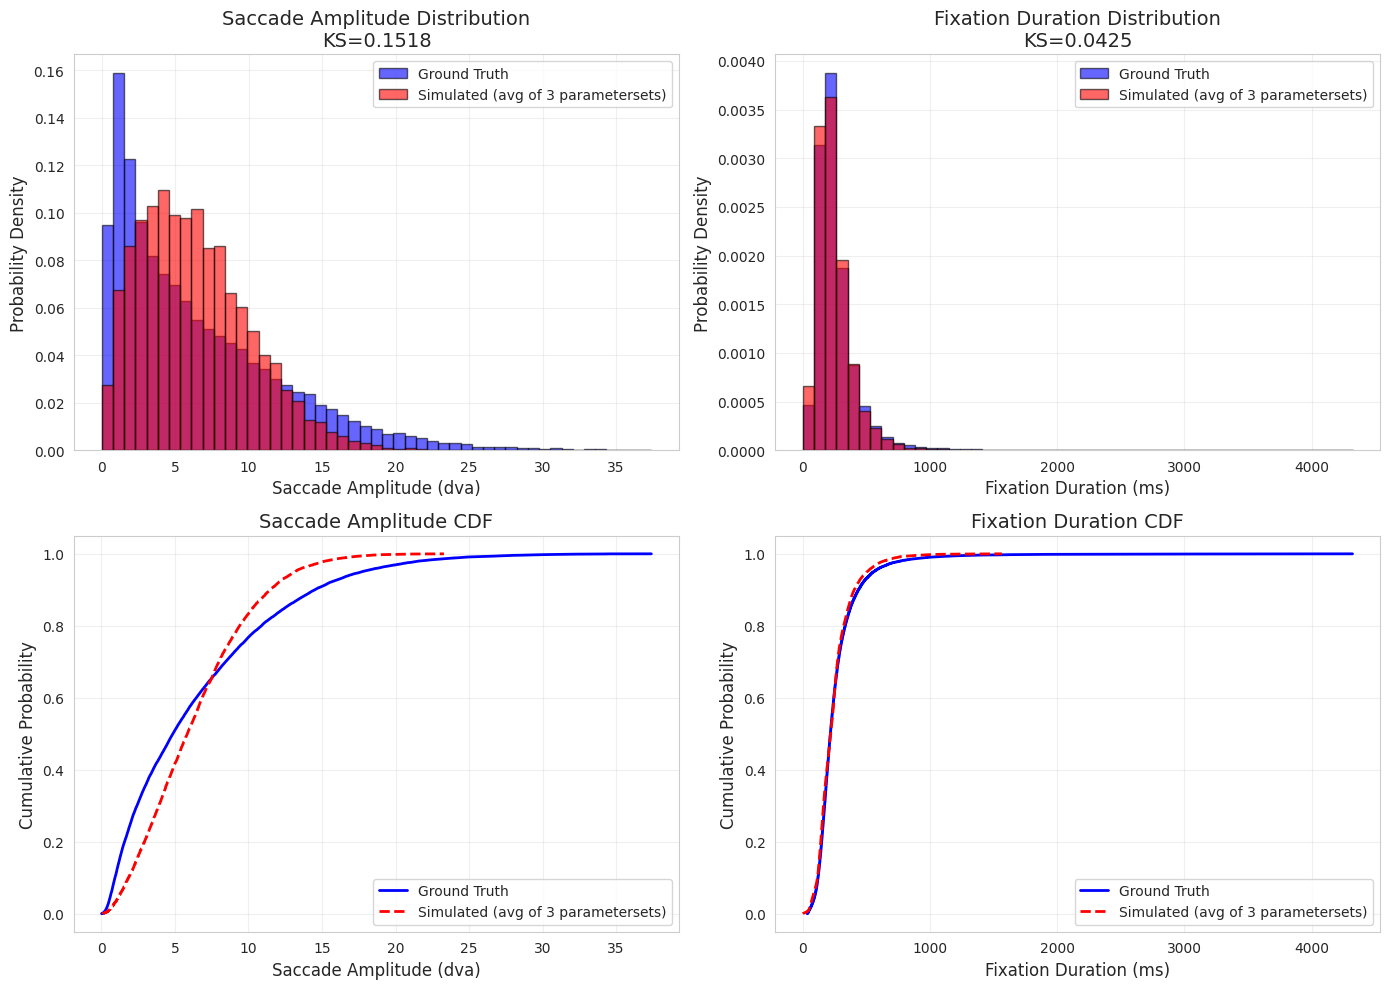

In [80]:
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ============ PARAMETERS ============
# Base filename pattern - will look for _0, _1, _2
simulate_file_pattern = f"/mnt/raid/data/anina/ScanDy/sorted_results/overfitting/best_cb_s13__std0.8_imgseed10_young"
test_group = 'young'

dataframe_files = {
    "young": '/mnt/raid/data/anina/ScanDy/PictureExample/PictureExample_Resized/parkinson_data/df_img_fovs_psycsci.csv',
}

gt_df = pd.read_csv(dataframe_files[test_group])
gt_amp_dva = gt_df["sac_amp_dva"].dropna().values
gt_dur_ms = gt_df["duration_ms"].dropna().values

print(f"Ground truth saccade amplitudes: mean={gt_amp_dva.mean():.2f}, median={np.median(gt_amp_dva):.2f}")
print(f"Ground truth durations: mean={gt_dur_ms.mean():.2f}, median={np.median(gt_dur_ms):.2f}")


sim_dfs = []
for i in range(3):
    simulate_file = f"{simulate_file_pattern}_{i}.csv.gz"
    if os.path.exists(simulate_file):
        sim_df = pd.read_csv(simulate_file, compression='gzip')
        sim_dfs.append(sim_df)
        print(f"  Parameterset Top {i}: mean_amp={sim_df['sac_amp_dva'].mean():.2f}, mean_dur={sim_df['duration_ms'].mean():.2f}")
    else:
        print(f"Warning: Simulated data file not found: {simulate_file}")

if sim_dfs:
    # Concatenate all dataframes to get combined distribution
    sim_df_combined = pd.concat(sim_dfs, ignore_index=True)
    sim_amp_dva = sim_df_combined["sac_amp_dva"].dropna().values
    sim_dur_ms = sim_df_combined["duration_ms"].dropna().values
    
    print(f"\nCombined simulated data from {len(sim_dfs)} iterations (top parametersets):")
    print(f"Simulated saccade amplitudes: mean={sim_amp_dva.mean():.2f}, median={np.median(sim_amp_dva):.2f}")
    print(f"Simulated durations: mean={sim_dur_ms.mean():.2f}, median={np.median(sim_dur_ms):.2f}")
    
    # Calculate KS statistics
    ks_amp, p_amp = stats.ks_2samp(gt_amp_dva, sim_amp_dva)
    ks_dur, p_dur = stats.ks_2samp(gt_dur_ms, sim_dur_ms)
    
    print(f"\nKS Statistics:")
    print(f"  Amplitude: KS={ks_amp:.4f}, p={p_amp:.4e}")
    print(f"  Duration: KS={ks_dur:.4f}, p={p_dur:.4e}")
else:
    print(f"No simulated data files found with pattern: {simulate_file_pattern}_*.csv.gz")
    sim_df_combined = None

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Amplitude Histogram
ax = axes[0, 0]
bins_amp = np.linspace(0, max(gt_amp_dva.max(), sim_amp_dva.max() if sim_df_combined is not None else gt_amp_dva.max()), 50)
ax.hist(gt_amp_dva, bins=bins_amp, alpha=0.6, label='Ground Truth', density=True, color='blue', edgecolor='black')
if sim_df_combined is not None:
    ax.hist(sim_amp_dva, bins=bins_amp, alpha=0.6, label=f'Simulated (avg of {len(sim_dfs)} parametersets)', density=True, color='red', edgecolor='black')
ax.set_xlabel('Saccade Amplitude (dva)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(f'Saccade Amplitude Distribution\nKS={ks_amp:.4f}' if sim_df_combined is not None else 'Saccade Amplitude Distribution', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Duration Histogram
ax = axes[0, 1]
bins_dur = np.linspace(0, max(gt_dur_ms.max(), sim_dur_ms.max() if sim_df_combined is not None else gt_dur_ms.max()), 50)
ax.hist(gt_dur_ms, bins=bins_dur, alpha=0.6, label='Ground Truth', density=True, color='blue', edgecolor='black')
if sim_df_combined is not None:
    ax.hist(sim_dur_ms, bins=bins_dur, alpha=0.6, label=f'Simulated (avg of {len(sim_dfs)} parametersets)', density=True, color='red', edgecolor='black')
ax.set_xlabel('Fixation Duration (ms)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title(f'Fixation Duration Distribution\nKS={ks_dur:.4f}' if sim_df_combined is not None else 'Fixation Duration Distribution', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

# Plot 3: Amplitude CDF
ax = axes[1, 0]
gt_amp_sorted = np.sort(gt_amp_dva)
gt_amp_cdf = np.arange(1, len(gt_amp_sorted)+1) / len(gt_amp_sorted)
ax.plot(gt_amp_sorted, gt_amp_cdf, label='Ground Truth', linewidth=2, color='blue')
if sim_df_combined is not None:
    sim_amp_sorted = np.sort(sim_amp_dva)
    sim_amp_cdf = np.arange(1, len(sim_amp_sorted)+1) / len(sim_amp_sorted)
    ax.plot(sim_amp_sorted, sim_amp_cdf, label=f'Simulated (avg of {len(sim_dfs)} parametersets)', linewidth=2, color='red', linestyle='--')
ax.set_xlabel('Saccade Amplitude (dva)', fontsize=12)
ax.set_ylabel('Cumulative Probability', fontsize=12)
ax.set_title('Saccade Amplitude CDF', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

# Plot 4: Duration CDF
ax = axes[1, 1]
gt_dur_sorted = np.sort(gt_dur_ms)
gt_dur_cdf = np.arange(1, len(gt_dur_sorted)+1) / len(gt_dur_sorted)
ax.plot(gt_dur_sorted, gt_dur_cdf, label='Ground Truth', linewidth=2, color='blue')
if sim_df_combined is not None:
    sim_dur_sorted = np.sort(sim_dur_ms)
    sim_dur_cdf = np.arange(1, len(sim_dur_sorted)+1) / len(sim_dur_sorted)
    ax.plot(sim_dur_sorted, sim_dur_cdf, label=f'Simulated (avg of {len(sim_dfs)} parametersets)', linewidth=2, color='red', linestyle='--')
ax.set_xlabel('Fixation Duration (ms)', fontsize=12)
ax.set_ylabel('Cumulative Probability', fontsize=12)
ax.set_title('Fixation Duration CDF', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

print(f"\nGround Truth Amplitude:")
print(f"  Mean: {gt_amp_dva.mean():.2f} dva")
print(f"  Median: {np.median(gt_amp_dva):.2f} dva")
print(f"  Std: {gt_amp_dva.std():.2f} dva")
print(f"  Min: {gt_amp_dva.min():.2f} dva")
print(f"  Max: {gt_amp_dva.max():.2f} dva")
print(f"  25th percentile: {np.percentile(gt_amp_dva, 25):.2f} dva")
print(f"  75th percentile: {np.percentile(gt_amp_dva, 75):.2f} dva")

if sim_df_combined is not None:
    print(f"\nSimulated Amplitude (combined from {len(sim_dfs)} iterations):")
    print(f"  Mean: {sim_amp_dva.mean():.2f} dva")
    print(f"  Median: {np.median(sim_amp_dva):.2f} dva")
    print(f"  Std: {sim_amp_dva.std():.2f} dva")
    print(f"  Min: {sim_amp_dva.min():.2f} dva")
    print(f"  Max: {sim_amp_dva.max():.2f} dva")
    print(f"  25th percentile: {np.percentile(sim_amp_dva, 25):.2f} dva")
    print(f"  75th percentile: {np.percentile(sim_amp_dva, 75):.2f} dva")
    
    print(f"\n  Difference in means: {sim_amp_dva.mean() - gt_amp_dva.mean():.2f} dva")
    print(f"  Ratio of means: {sim_amp_dva.mean() / gt_amp_dva.mean():.2f}x")

print(f"\nGround Truth Duration:")
print(f"  Mean: {gt_dur_ms.mean():.2f} ms")
print(f"  Median: {np.median(gt_dur_ms):.2f} ms")
print(f"  Std: {gt_dur_ms.std():.2f} ms")

if sim_df_combined is not None:
    print(f"\nSimulated Duration (combined from {len(sim_dfs)} iterations):")
    print(f"  Mean: {sim_dur_ms.mean():.2f} ms")
    print(f"  Median: {np.median(sim_dur_ms):.2f} ms")
    print(f"  Std: {sim_dur_ms.std():.2f} ms")
    
    print(f"\n  Difference in means: {sim_dur_ms.mean() - gt_dur_ms.mean():.2f} ms")
    print(f"  Ratio of means: {sim_dur_ms.mean() / gt_dur_ms.mean():.2f}x")

plt.show()